# **Advanced Machine Learning and MLOps: SuperKart**

## Description


**Business Context**

A sales forecast predicts future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action. Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. 
An accurate sales forecast process has many benefits, which include improved decision-making about the future and the reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establishes benchmarks that can be used to assess trends in the future.

**Objective**

They hired you as an MLOps Engineer, and your task is to build an automated MLOps pipeline with CI/CD to deliver accurate and reliable sales forecasts. The objective is to leverage historical sales data, industry trends, and the current pipeline status to predict weekly, monthly, quarterly, and annual revenues. By automating data ingestion, preprocessing, model training, evaluation, and deployment, the pipeline will ensure scalability, consistency, and minimal manual intervention. With CI/CD integration, forecasts will be continuously updated and seamlessly deployed, enabling different business verticals to plan sales operations by region, optimize supply chain procurement, reduce risks in sales pipelines, and establish benchmarks for future trend analysis. Ultimately, this solution will enhance decision-making, streamline planning efforts, and drive operational efficiency and business growth.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


## Install and Import required Library

In [1]:
!pip install pandas numpy==2.0.2 streamlit==1.43.2 "huggingface_hub>=0.33.5,<2.0" joblib==1.5.1 scikit-learn==1.6.0 requests==2.32.3 xgboost==2.1.4 mlflow==3.0.1 python-dotenv matplotlib==3.10.0 seaborn==0.13.2

zsh:1: command not found: pip


In [2]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi
from huggingface_hub.utils import RepositoryNotFoundError, HfHubHTTPError
from huggingface_hub import HfApi, create_repo

# **Loading the dataset**

In [3]:
path = 'dataset/SuperKart.csv'

data = pd.read_csv(path)

In [4]:
df=data.copy()

# **Data Overview**

In [5]:
df.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [6]:
df.dtypes

Product_Id                    object
Product_Weight               float64
Product_Sugar_Content         object
Product_Allocated_Area       float64
Product_Type                  object
Product_MRP                  float64
Store_Id                      object
Store_Establishment_Year       int64
Store_Size                    object
Store_Location_City_Type      object
Store_Type                    object
Product_Store_Sales_Total    float64
dtype: object

In [7]:
df.shape

(8763, 12)

Observation: There are 8763 row items and 12 columns in the data given

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


Observation: There are no null values and 7 are categorical columns and 5 are numerical columns

### Checking for missing values

In [9]:
# checking for null values
df.isnull().sum()

Product_Id                   0
Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_Type                 0
Product_MRP                  0
Store_Id                     0
Store_Establishment_Year     0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
dtype: int64

Observation: As highlighted earlier, there are no null values

### Dropping the duplicate values

In [10]:
# checking for duplicate values
df.duplicated().sum()

np.int64(0)

Observation: There are no duplicate values as well

### Statistical summary of the data



**Let's check the statistical summary of the data.**

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000


**Observation:**

*   All weight, MRP and sales are following the normal distribution where both mean and 50% are almost same and the max is almost 2x of mean

* Area is a bit right skewed


In [12]:
categorical_cols = list(df.select_dtypes("object").columns)
numeric_columns = list(df.select_dtypes(include=['int64', 'float64']))
target = 'Product_Store_Sales_Total'

In [13]:
for item in categorical_cols:
  print(100*df[item].value_counts(dropna = False)/df[item].shape[0])
  print('-' * 50)

Product_Id
FD6114    0.011412
FD8349    0.011412
DR3530    0.011412
NC5926    0.011412
FD3575    0.011412
            ...   
FD2396    0.011412
FD681     0.011412
FD8077    0.011412
DR3118    0.011412
FD306     0.011412
Name: count, Length: 8763, dtype: float64
--------------------------------------------------
Product_Sugar_Content
Low Sugar    55.745749
Regular      25.687550
No Sugar     17.334246
reg           1.232455
Name: count, dtype: float64
--------------------------------------------------
Product_Type
Fruits and Vegetables    14.253110
Snack Foods              13.111948
Frozen Foods              9.254821
Dairy                     9.083647
Household                 8.444597
Baking Goods              8.170718
Canned                    7.725665
Health and Hygiene        7.166495
Meat                      7.052379
Soft Drinks               5.922629
Breads                    2.282323
Hard Drinks               2.122561
Others                    1.723154
Starchy Foods             

Observation:

* Sugar content is having an anomalous value "reg", looks like a typo, we will fix it

In [14]:
unique_counts = df['Product_Sugar_Content'].value_counts()
print(unique_counts)

Product_Sugar_Content
Low Sugar    4885
Regular      2251
No Sugar     1519
reg           108
Name: count, dtype: int64


In [15]:
# Replace the reg value to Regular
df['Product_Sugar_Content'] = df['Product_Sugar_Content'].replace(['reg'],"Regular")

df = df.astype({"Product_Sugar_Content": object})

unique_counts = df['Product_Sugar_Content'].value_counts()
print(unique_counts)

Product_Sugar_Content
Low Sugar    4885
Regular      2359
No Sugar     1519
Name: count, dtype: int64


In [16]:
unique_counts = df['Product_Type'].value_counts()
print(unique_counts)

Product_Type
Fruits and Vegetables    1249
Snack Foods              1149
Frozen Foods              811
Dairy                     796
Household                 740
Baking Goods              716
Canned                    677
Health and Hygiene        628
Meat                      618
Soft Drinks               519
Breads                    200
Hard Drinks               186
Others                    151
Starchy Foods             141
Breakfast                 106
Seafood                    76
Name: count, dtype: int64


Observation:

* Product type is too diverse, lets see whether we can label them after the EDA


# **Exploratory Data Analysis (EDA)**

### **ED Functions**

In [17]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

In [18]:
def plot_histogram_boxplot(data, features, figsize=(16, 12), kde=False, bins=None):
    """
    Generates a grid of combined boxplots and histograms.

    data: pandas DataFrame
    features: A single column name (string) or a list of column names
    figsize: Overall size of the figure
    kde: Whether to show the density curve on histograms
    bins: Number of bins for histograms
    """
    if not isinstance(features, list):
        features = [features]

    n_features = len(features)
    n_cols = min(n_features, 3)
    n_rows = int(np.ceil(n_features / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, constrained_layout=True)
    axes = np.array(axes).flatten()

    for i, feature in enumerate(features):
        current_ax = axes[i]
        current_ax.set_axis_off()

        # FIX: Use GridSpecFromSubplotSpec for a robust nested grid
        sub_gs = GridSpecFromSubplotSpec(
            2, 1,
            subplot_spec=current_ax.get_subplotspec(),
            height_ratios=[0.25, 0.75],
            hspace=0
        )

        ax_box = fig.add_subplot(sub_gs[0])
        ax_hist = fig.add_subplot(sub_gs[1], sharex=ax_box)

        plt.setp(ax_box.get_xticklabels(), visible=False)

        # Plotting
        sns.boxplot(data=data, x=feature, ax=ax_box, showmeans=True, color="violet")
        ax_box.set_xlabel('')
        ax_box.set_title(f'Distribution of {feature}', weight='bold')

        plot_params = {'data': data, 'x': feature, 'kde': kde, 'ax': ax_hist}
        if bins:
            sns.histplot(**plot_params, bins=bins)
        else:
            sns.histplot(**plot_params)

        ax_hist.axvline(data[feature].mean(), color="green", linestyle="--", label=f"Mean: {data[feature].mean():.2f}")
        ax_hist.axvline(data[feature].median(), color="black", linestyle="-", label=f"Median: {data[feature].median():.2f}")
        ax_hist.legend(loc="upper right")

    # Hide any unused subplots
    for i in range(n_features, len(axes)):
        axes[i].set_axis_off()

    plt.show()

In [19]:
def show_pairplot(data, diag_kind = 'kde', height = 2, hue = None):
  '''
  Description: Function to plot a barplot with labeled percentage or count
  Parameters:
    data: pandas.core.frame.DataFrame, required
      The DataFrame of the two-dimensional tabular data
    diag_kind: str, optional
      The type of pairplot diagram, default: kde
    height: int, optional
      The plot size in inches, default: 2
    hue: str, optional
      To show the hue, default: None
  '''
  if hue:
    ax = sns.pairplot(data = data, diag_kind = 'kde', height = height, hue = hue)
    ax.fig.suptitle('Relationship of Numerical Variables with regards to ' + hue, y = 1.005, size = 11)
  else:
    ax = sns.pairplot(data = data, diag_kind = 'kde', height = height)
    ax.fig.suptitle('Relationship of Numerical Variables', y = 1.005, size = 11)

  plt.show()

In [20]:
def show_category_price_plot(data, category, price='Price', plot_type='box', height=6, aspect=2):
    '''
    Description: Function to compare a categorical variable against Price.
    Parameters:
        data: pandas.DataFrame, required
            The DataFrame containing the data.
        category: str, required
            The name of the categorical column.
        price: str, optional
            The name of the continuous price column, default: 'Price'.
        plot_type: str, optional
            The style of plot: 'box', 'violin', or 'bar', default: 'box'.
        height: int, optional
            The height of the plot in inches, default: 6.
        aspect: int, optional
            The ratio of width to height, default: 2.
    '''
    # Set plot style
    sns.set_theme(style="whitegrid")

    # Sort categories by median price for better readability
    order = data.groupby(category)[price].median().sort_values(ascending=False).index

    if plot_type == 'box':
        g = sns.catplot(data=data, x=category, y=price, kind="box",
                        order=order, height=height, aspect=aspect, palette="viridis")
    elif plot_type == 'violin':
        g = sns.catplot(data=data, x=category, y=price, kind="violin",
                        order=order, height=height, aspect=aspect, palette="muted")
    elif plot_type == 'bar':
        # Shows mean with confidence interval
        g = sns.catplot(data=data, x=category, y=price, kind="bar",
                        order=order, height=height, aspect=aspect, palette="magma")

    # Formatting
    g.fig.suptitle(f'Distribution of {price} across {category}', y=1.02, size=14)
    plt.xticks(rotation=45)
    plt.show()

In [21]:
def plot_labeled_barplots(data, features, perc=False, n=None, figsize=(20, 15)):
    """
    Generates a grid of bar plots with labels.

    data: pandas DataFrame
    features: A single column name (string) or a list of column names
    perc: Whether to display percentages instead of count (default is False)
    n: Displays the top n category levels (default is None, i.e., display all levels)
    figsize: Overall size of the figure for the grid
    """
    # Ensure 'features' is a list for consistent iteration
    if not isinstance(features, list):
        features = [features]

    # Calculate grid dimensions
    n_features = len(features)
    n_cols = min(n_features, 3)  # Max 3 columns for readability
    n_rows = int(np.ceil(n_features / n_cols))

    # Create the main figure and subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, constrained_layout=True)
    axes = np.array(axes).flatten()

    # Loop through each feature
    for i, feature in enumerate(features):
        ax = axes[i]
        total = len(data[feature])

        # Create the bar plot on the specified axis
        sns.countplot(
            data=data,
            x=feature,
            palette="Paired",
            order=data[feature].value_counts().index[:n],
            ax=ax,
        )

        ax.set_title(f"Distribution of {feature}", weight="bold")
        ax.tick_params(axis='x', labelrotation=90) # Rotate x-axis labels

        # Annotate each bar with count or percentage
        for p in ax.patches:
            if perc:
                label = f"{100 * p.get_height() / total:.1f}%"
            else:
                label = f"{p.get_height()}"

            ax.annotate(
                label,
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center",
                va="center",
                size=11,
                xytext=(0, 5),
                textcoords="offset points",
            )

    # Hide any unused subplots
    for i in range(n_features, len(axes)):
        axes[i].set_axis_off()

    plt.show()

In [22]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [23]:
def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")


    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )
    for ax in axs.flat:
            ax.tick_params(axis='x', labelrotation=90)
    plt.tight_layout()
    plt.show()

### Univariate Analysis

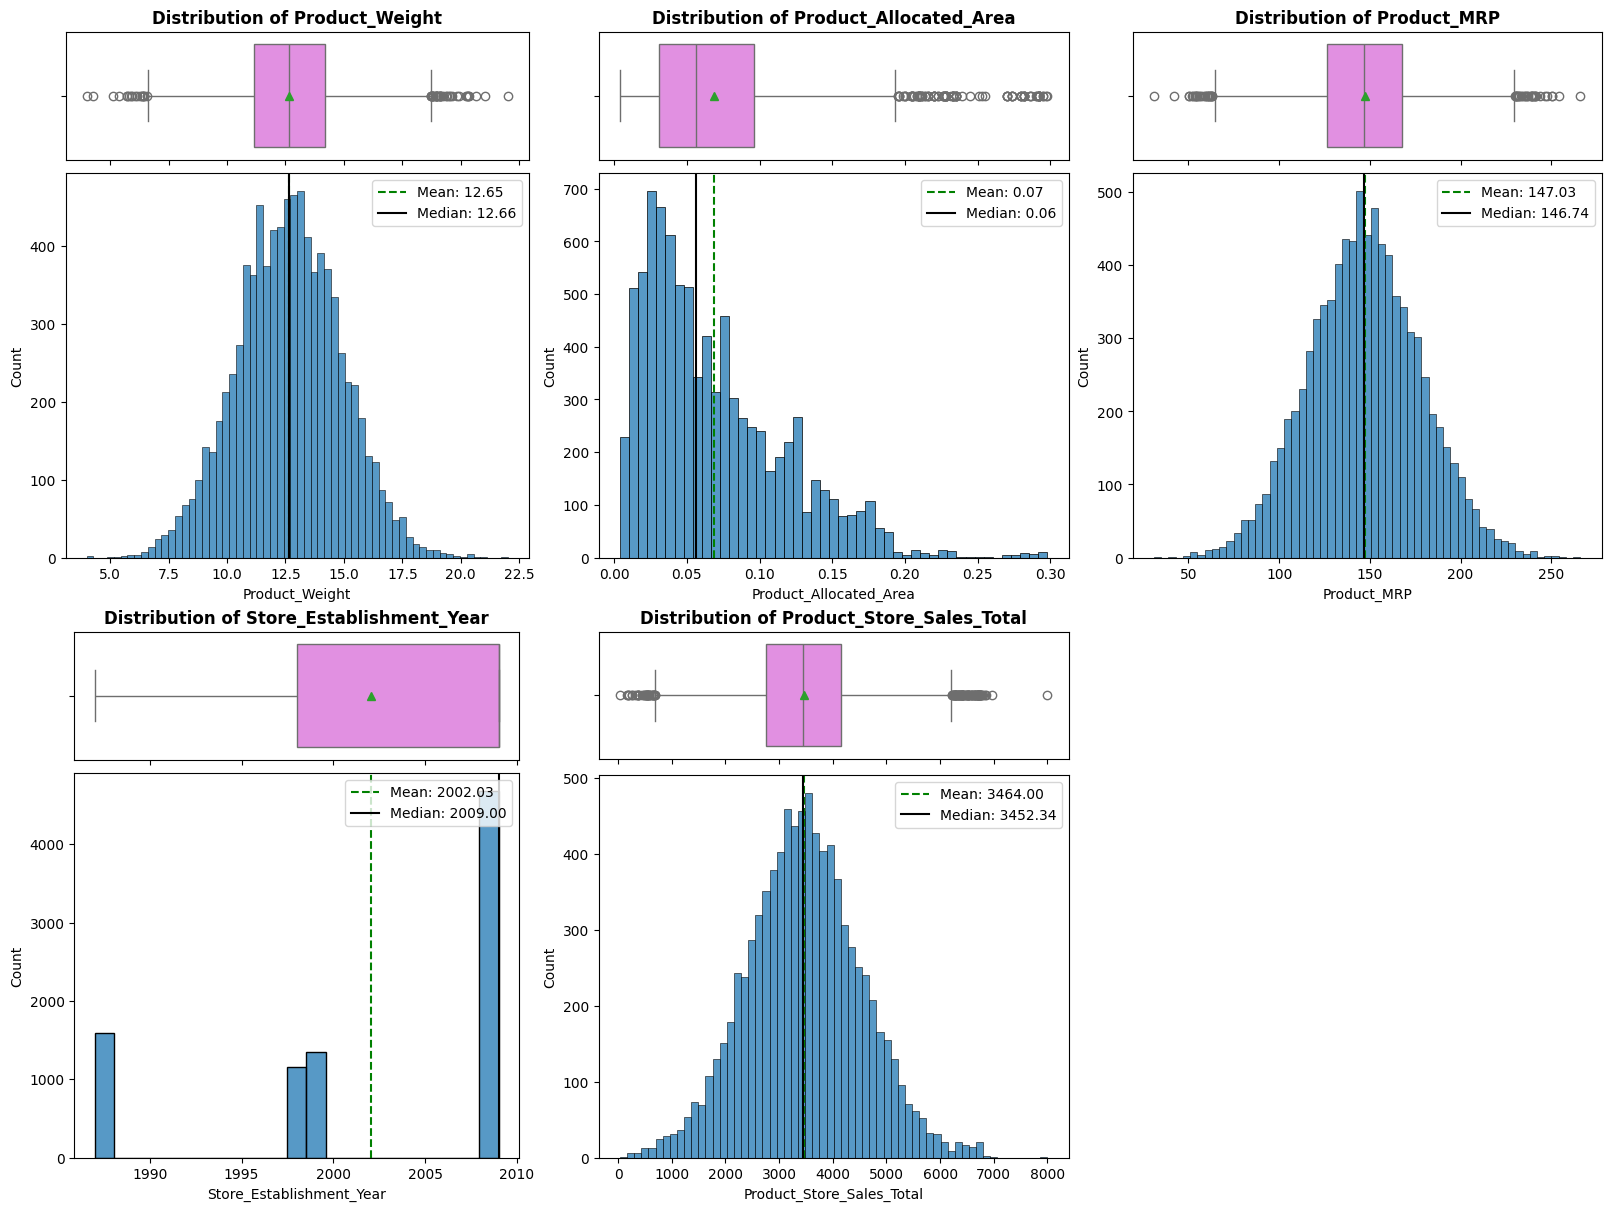

In [24]:
# outlier detection using boxplot
plot_histogram_boxplot(data, numeric_columns)

**Observation**

* As highlighted MRP, sales, weight follows the normal distribution
* Area is more of right skewed
* year is not that mandatory to find a distribution


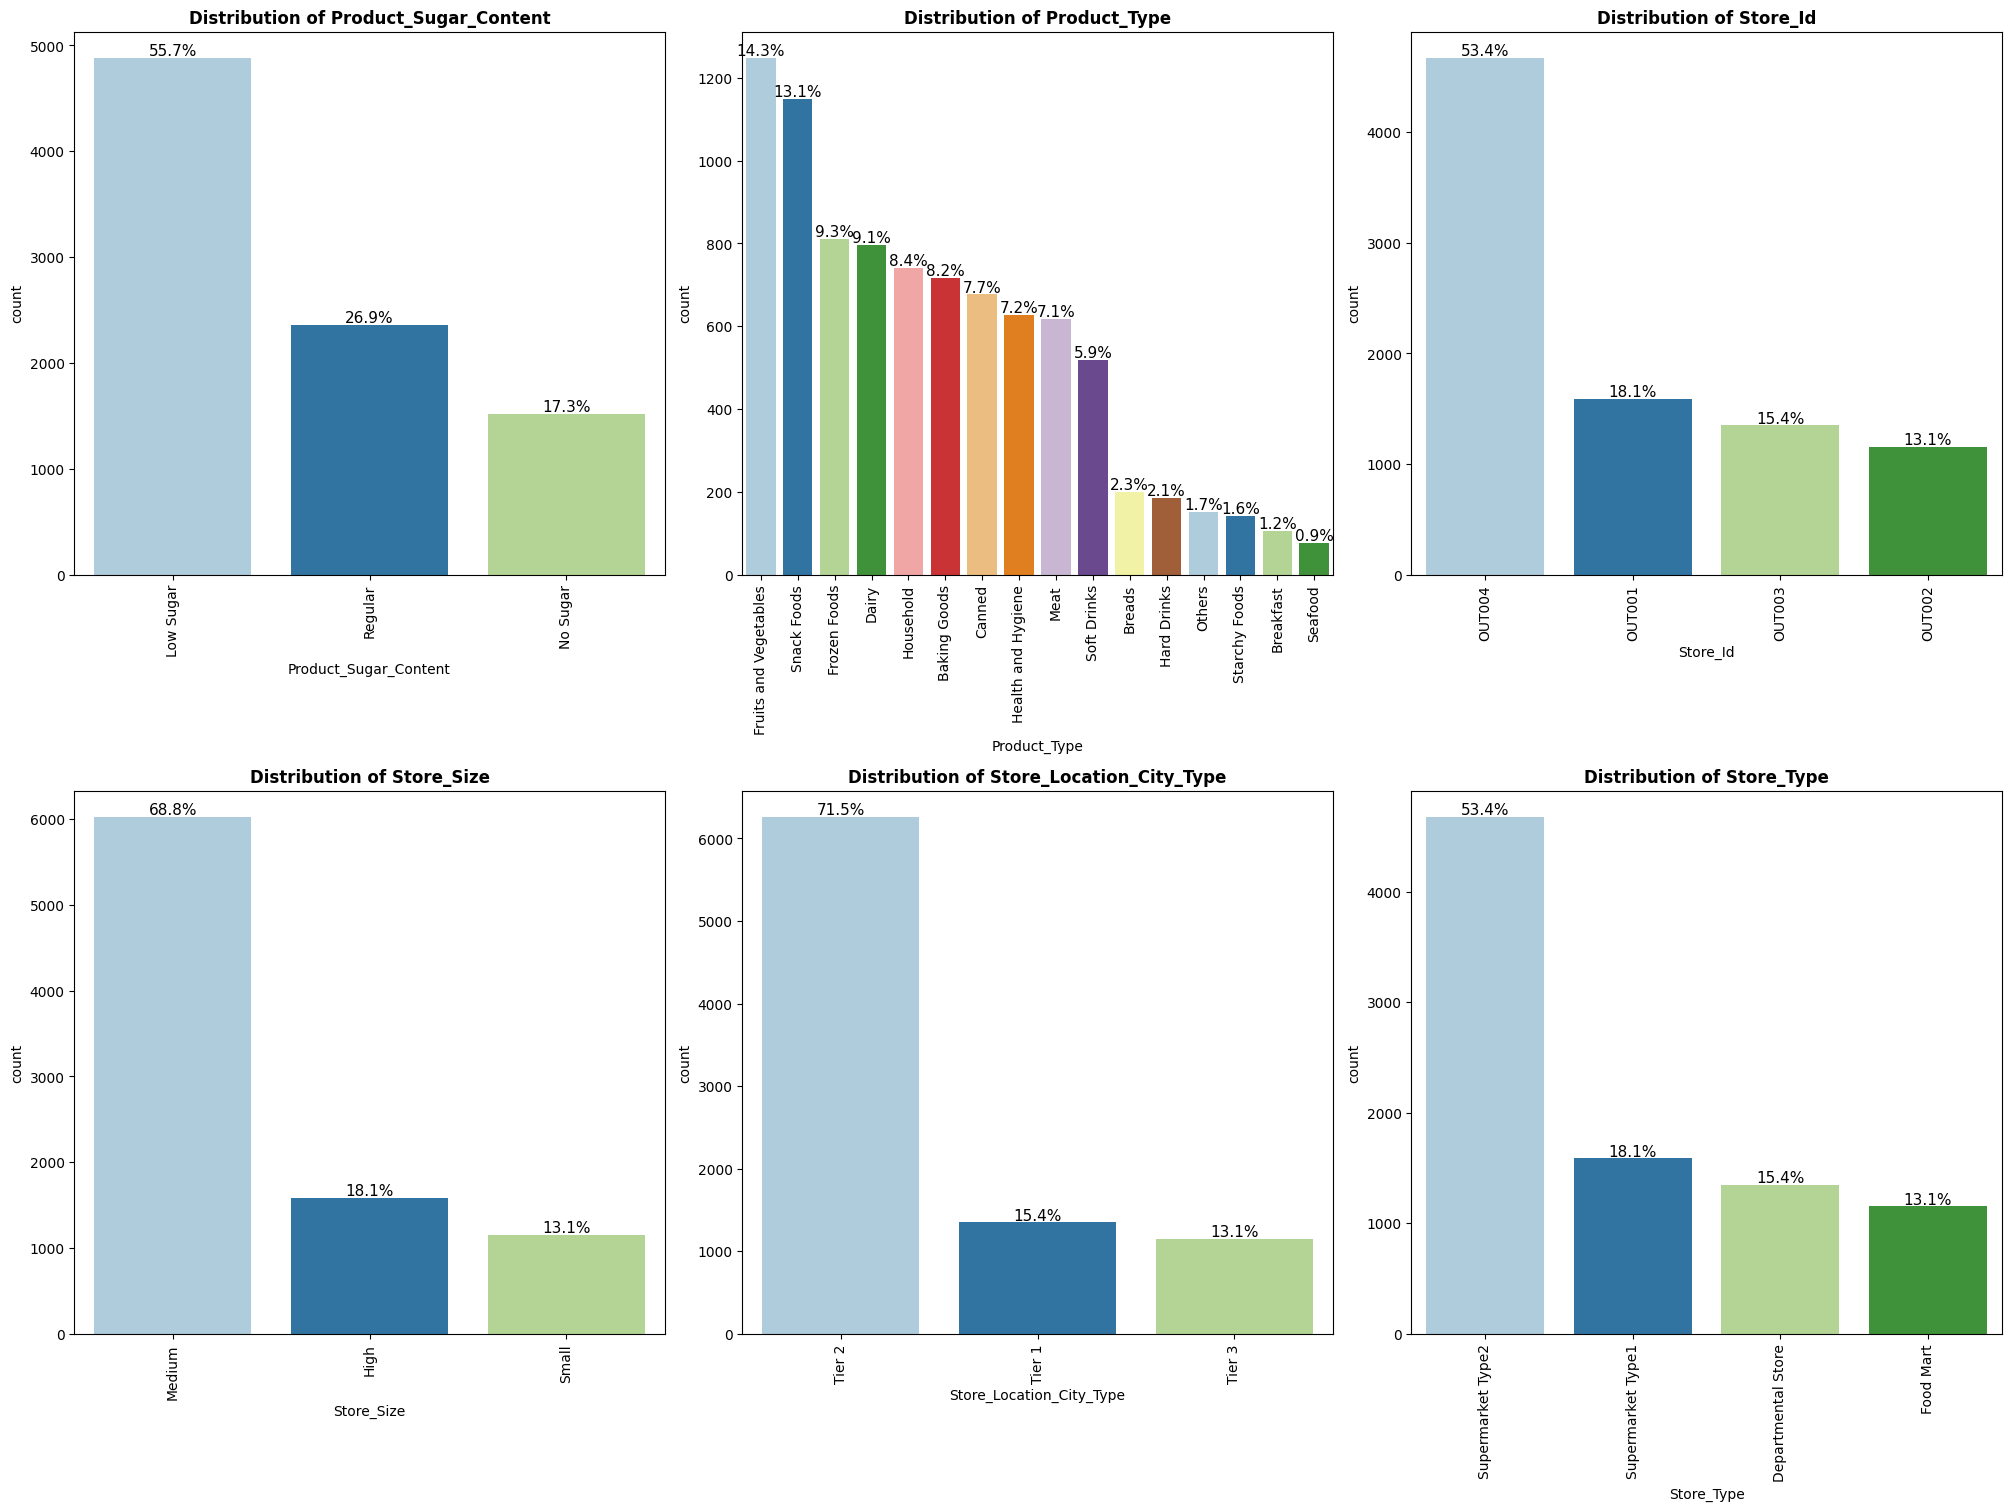

In [25]:
other_columns = categorical_cols

other_columns.remove('Product_Id')

plot_labeled_barplots(df, other_columns, perc=True)

Observation:

* Low sugar products are almost 56% out of overall product sales with sugar content
* the product type are almost with the mean of 7% with max of 14% and min of 1%
* Medium store size is having 69% of the products sales
* Tier 2 stores are having 72% of the sales

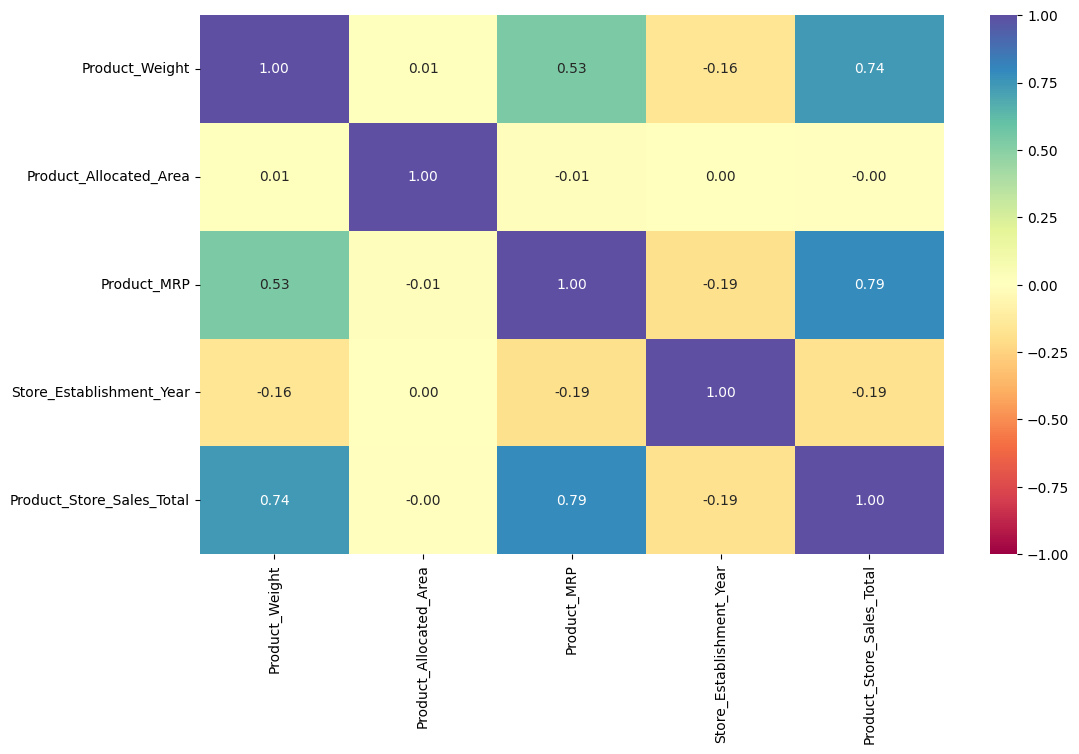

In [26]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(12, 7))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

**Observation:**
* Sale is strongly correlated with MRP and weight

Lets try bivariant analysis

## Bivariate Analysis

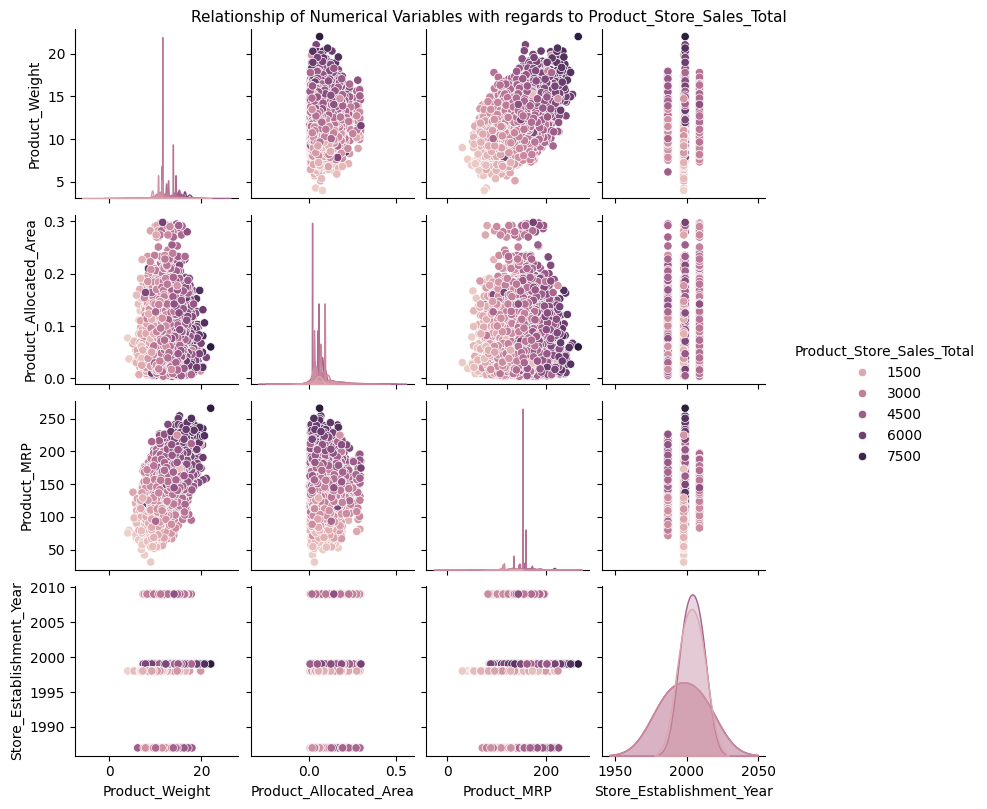

In [27]:
show_pairplot(data = df[numeric_columns], hue = target)

**Observations:**
* MRP is the Strongest Predictor: Higher sales (darker points) are clearly concentrated in the higher Product_MRP ranges. Price appears to be the primary driver of total sales value.

* Price Clustering: Product_MRP shows four distinct peaks, indicating that products are priced in specific tiers rather than a continuous range.

* Shelf Space Efficiency: Most products have a low Allocated_Area. High sales occur across all area sizes, suggesting that increasing shelf space doesn't automatically guarantee higher sales.

* No Correlation with Weight: Product_Weight shows no significant relationship with sales or price, indicating that "heaviness" is not a factor in product performance.

* Establishment Stability: Sales performance is consistent across stores regardless of the Establishment_Year, though newer stores show slightly denser data clusters.


**Let's see how the target variable varies across main columns**

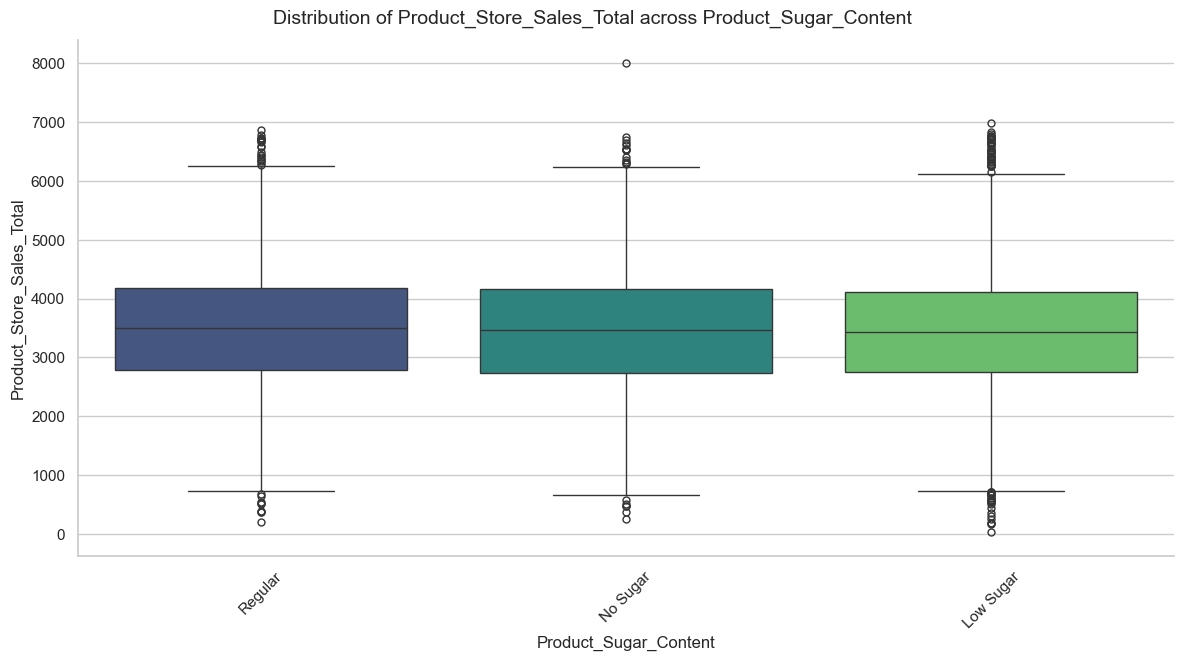

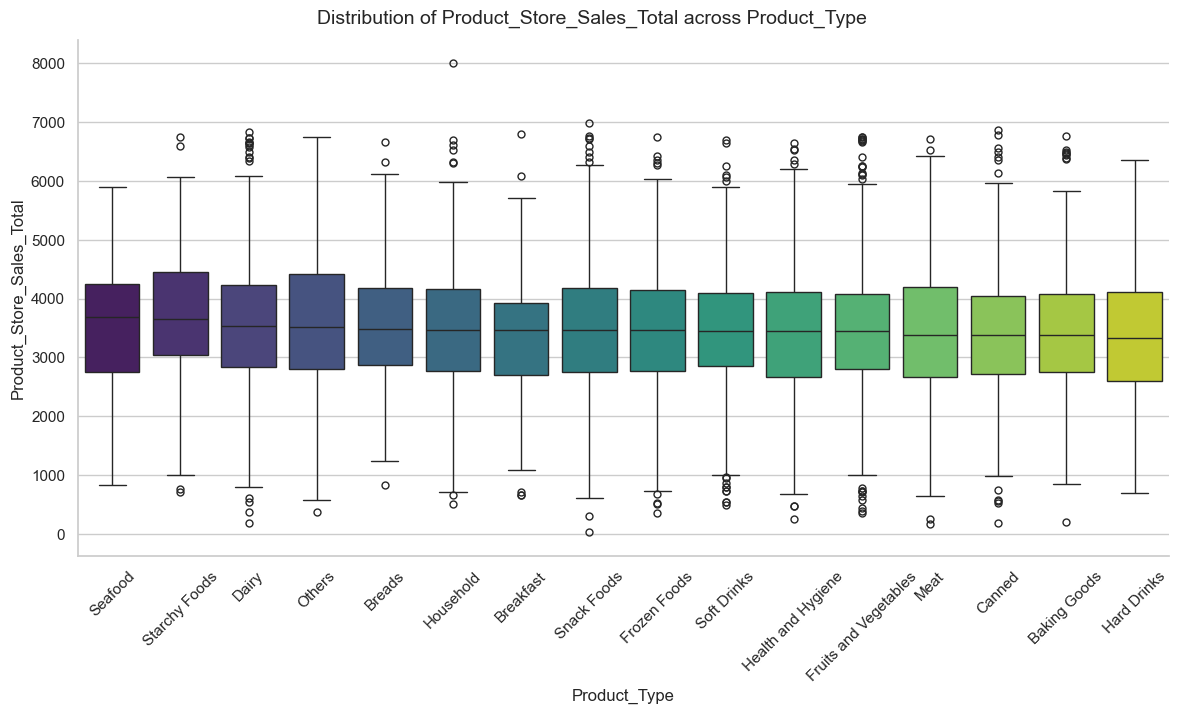

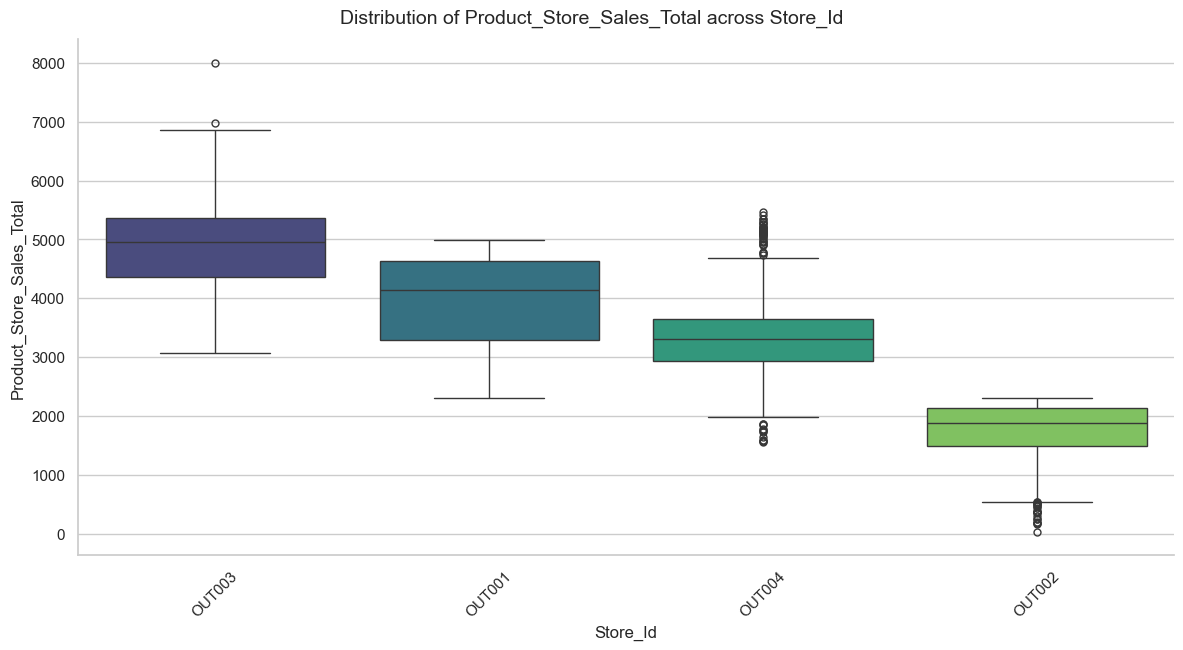

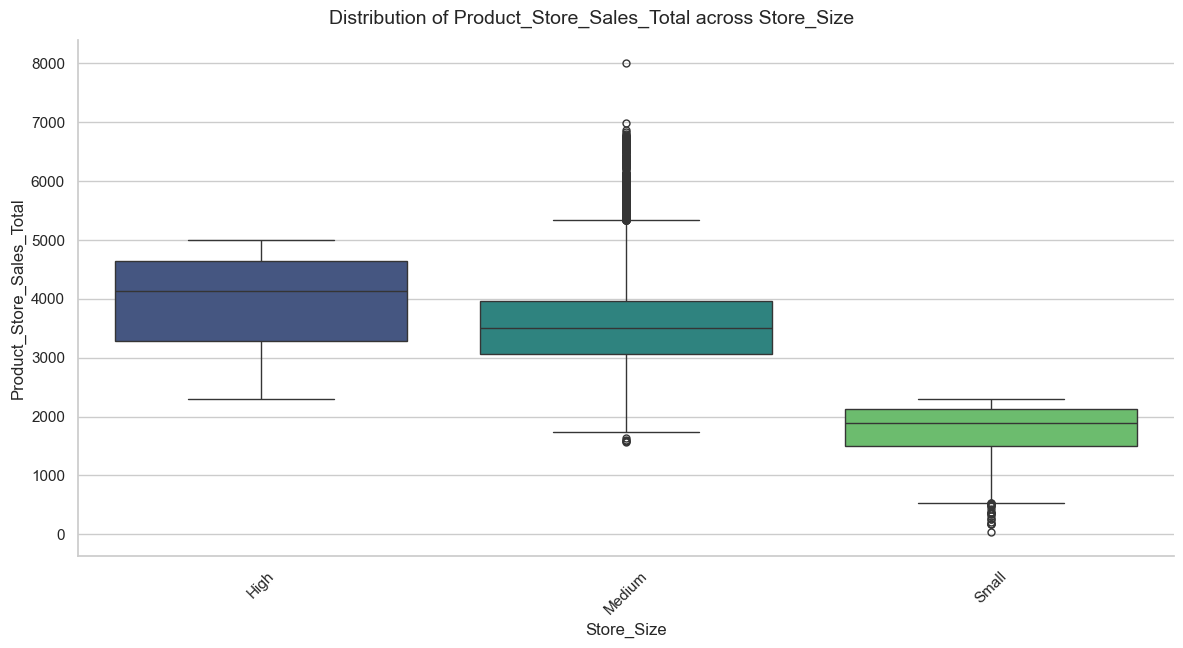

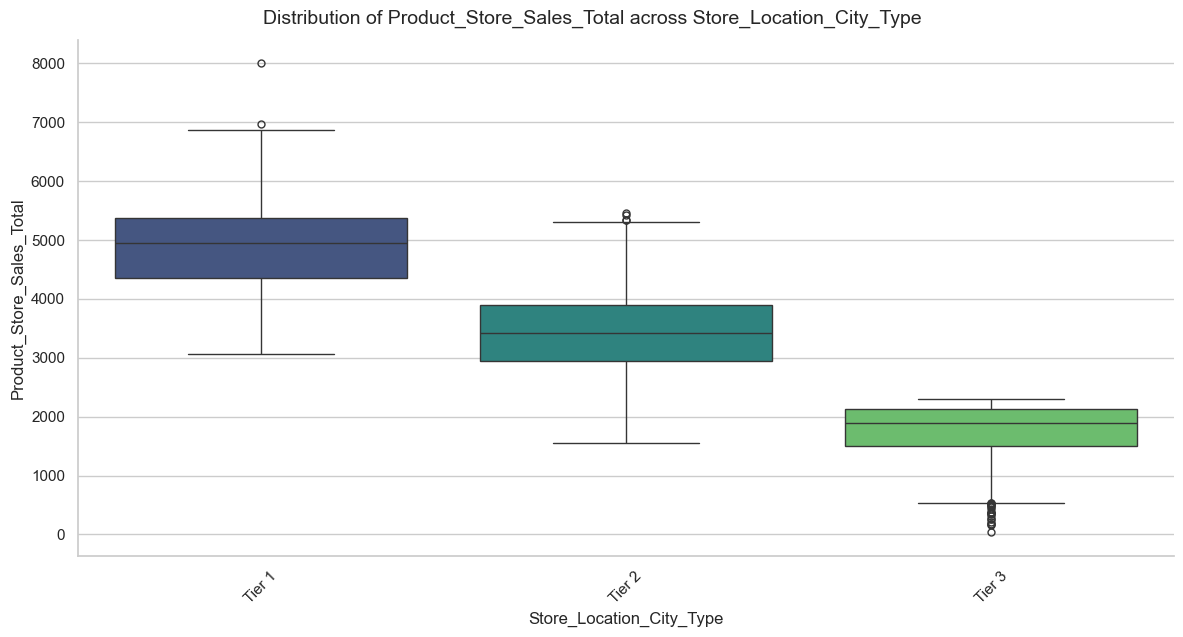

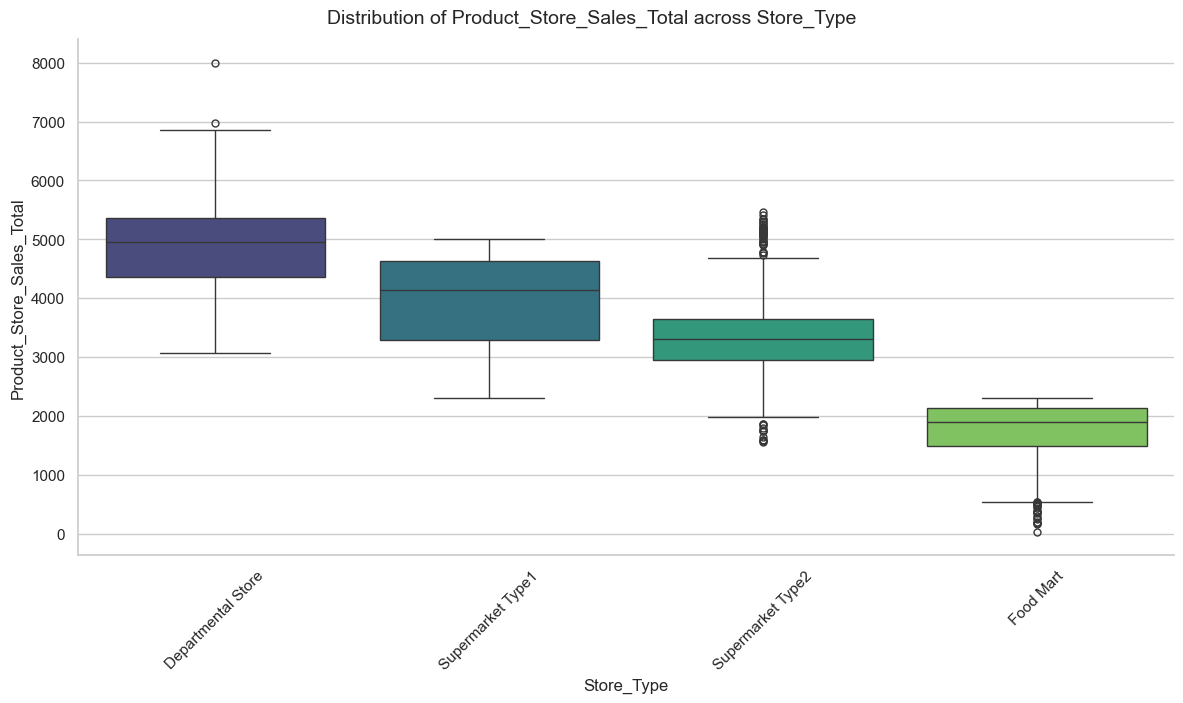

In [28]:
for i in categorical_cols:
  if i != target:
    show_category_price_plot(data=df, category=i, price=target)

**Observation:**
* Top Performers: Departmental Stores, High-sized stores, and those in Tier 1 cities generate the highest median sales.

* Store ID Impact: OUT003 is the most successful location, while OUT002 performs the poorest.

* Store Size Correlation: Larger stores consistently outperform medium and small ones.

* Location Matters: Sales decrease progressively from Tier 1 (highest) to Tier 3 (lowest) city types.

* Minimal Product Influence: Sugar content and product category have a negligible impact on total sales compared to store-level factors.

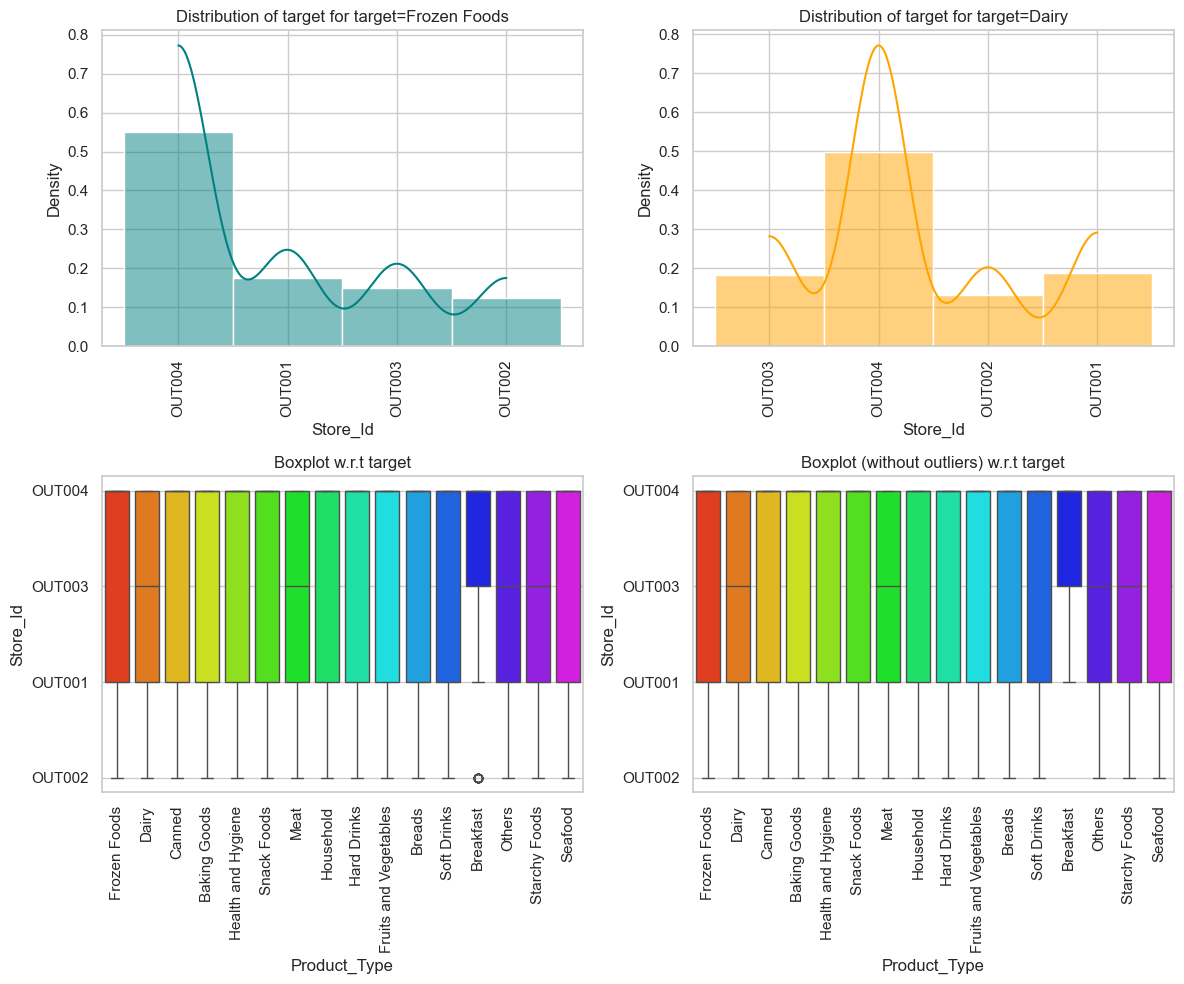

In [29]:
distribution_plot_wrt_target(data, 'Store_Id', 'Product_Type')

**Observation:**
* Primary Sales Drivers: Departmental Stores, High-sized stores, and Tier 1 city locations yield the highest median sales.

* Store Performance: OUT003 is the top-performing store ID, while OUT002 and Food Marts consistently underperform.

* Product Impact: Sugar content and Product Type have a negligible effect on total sales compared to store-level factors.

* Category Distribution: Store OUT004 shows the highest density for Frozen Foods and Dairy inventory.

* Pricing: Product MRP is the strongest numerical predictor, with higher price points correlating directly with higher total sales.

Store with highest average MRP: OUT003


Text(0.5, 1.0, 'Store with highest average MRP')

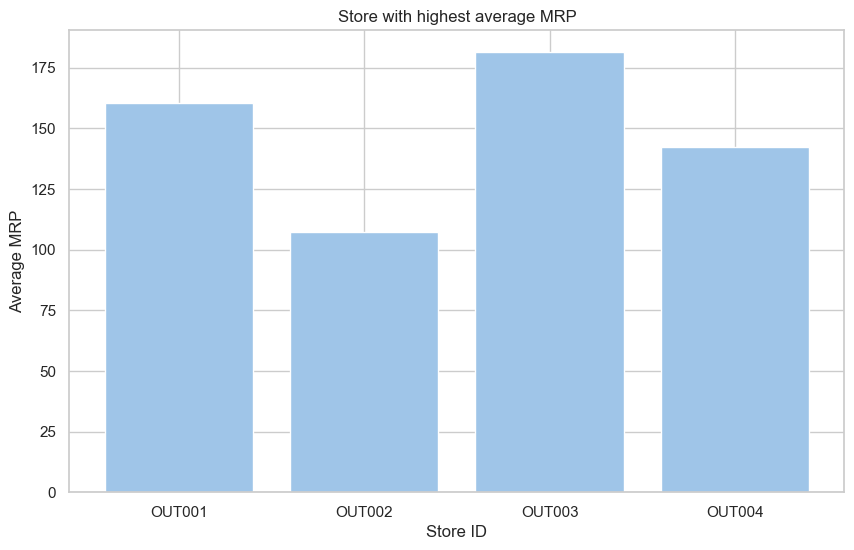

In [30]:
# Group by Store_Id and calculating the average MRP for each store
store_average_mrp = df.groupby('Store_Id')['Product_MRP'].mean()

# Finding the store with the highest average MRP
highest_avg_mrp_store = store_average_mrp.idxmax()

print("Store with highest average MRP:", highest_avg_mrp_store)

# Highlight the store with the highest average MRP
plt.figure(figsize=(10, 6))
plt.bar(store_average_mrp.index, store_average_mrp.values, color='#9fc5e8')
plt.xlabel('Store ID')
plt.ylabel('Average MRP')
plt.title('Store with highest average MRP')

Observation:



*   Primary Sales Drivers: Departmental Stores, High-sized stores, and Tier 1 cities yield the highest median sales.


* Top Performance: OUT003 is the leading store, driven by having the highest Average MRP.

* MRP Correlation: Product_MRP is the strongest numerical predictor of total sales value.

* Low Impact Factors: Sugar content and specific Product Types have a negligible effect on sales compared to store characteristics.

* Bottom Performers: Food Marts, store OUT002, and Tier 3 cities consistently underperform.



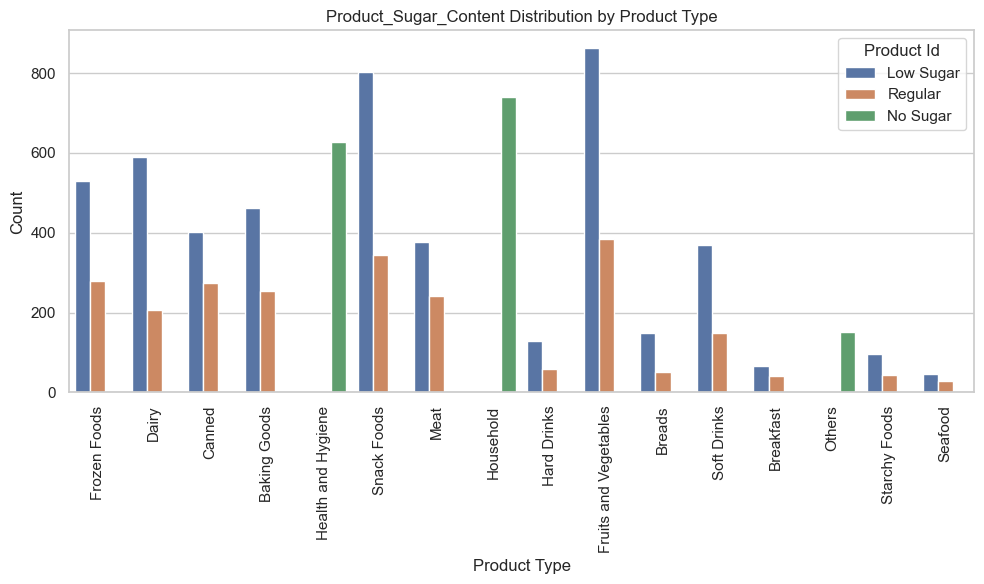

In [31]:
# Create a count plot for Product_Id against Product_Type
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Product_Type', hue='Product_Sugar_Content', palette='deep')
plt.xlabel('Product Type')
plt.ylabel('Count')
plt.title('Product_Sugar_Content Distribution by Product Type')
plt.xticks(rotation=90)
plt.legend(title='Product Id')
plt.tight_layout()

plt.show()

**Observation:**
* No much insights

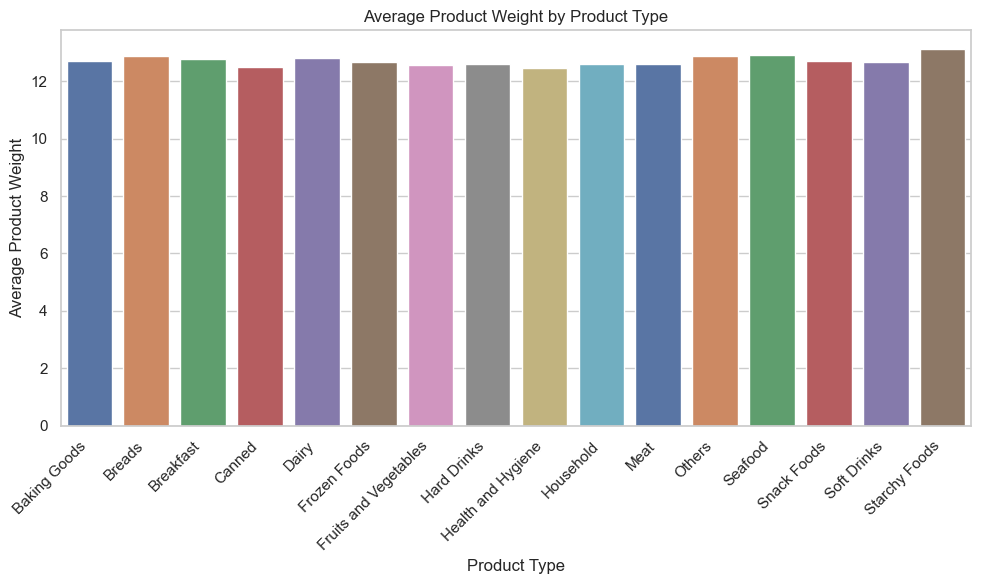

In [32]:
average_weight_by_type = df.groupby('Product_Type')['Product_Weight'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=average_weight_by_type, x='Product_Type', y='Product_Weight', palette='deep')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Product Type')
plt.ylabel('Average Product Weight')
plt.title('Average Product Weight by Product Type')
plt.tight_layout()
plt.show()

**Observation:**
* No much insights

# **Data Preprocessing**

In [33]:
df1 = df.copy()

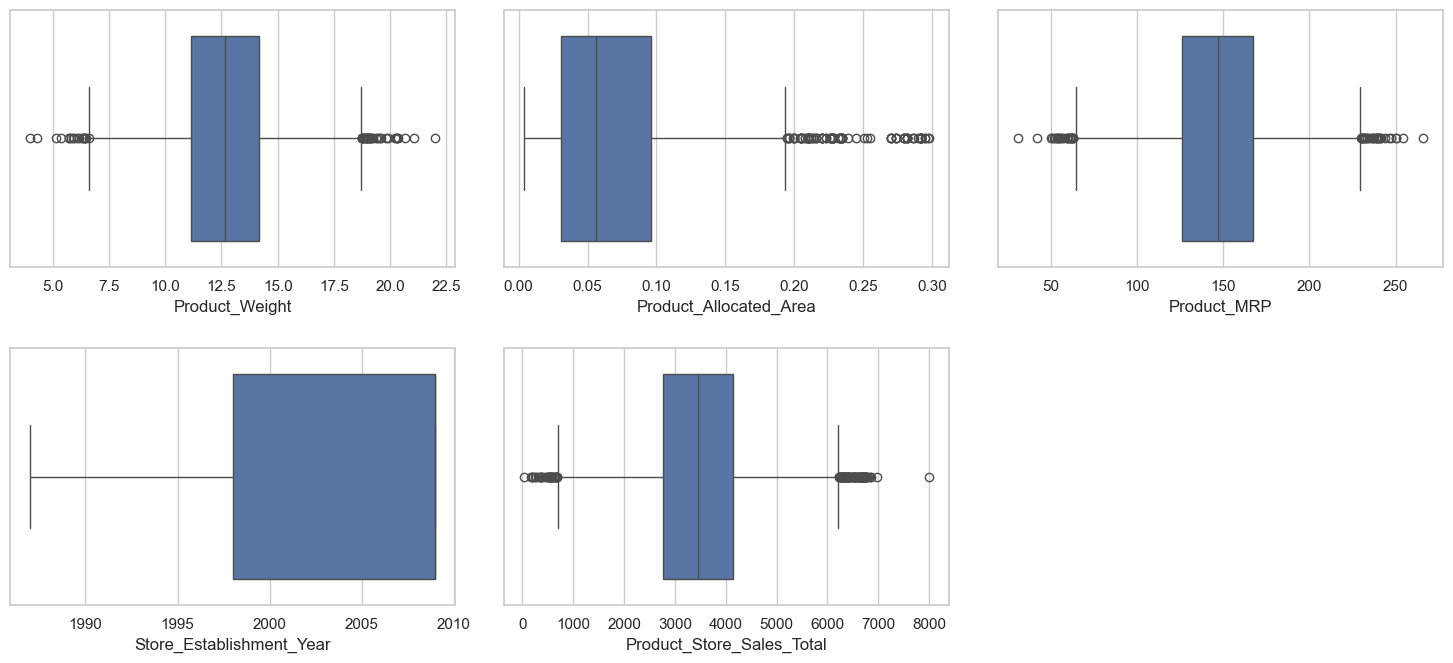

Outliers using Z-Score Method:
      Product_Weight  Product_Allocated_Area  Product_MRP  \
231            21.04                     NaN          NaN   
551            19.37                     NaN          NaN   
701            20.35                     NaN          NaN   
736             5.81                     NaN          NaN   
891            20.22                     NaN          NaN   
1945            5.72                     NaN          NaN   
2497            4.28                     NaN          NaN   
3165            5.71                     NaN          NaN   
3258           19.40                     NaN          NaN   
3967            5.13                     NaN          NaN   
4082           20.30                     NaN          NaN   
4115           19.61                     NaN          NaN   
4356           22.00                     NaN        266.0   
4423           19.82                     NaN          NaN   
4462            5.93                     NaN          

In [34]:
import scipy.stats as stats

# Outlier check for particular columns
num_cols = df1.select_dtypes(include=np.number).columns.tolist()

# Creating an empty DataFrame to store outliers based on Z-score
outliers_zscore = pd.DataFrame()

# Iterate over the numerical columns and find outliers using Z-score
for col in num_cols:
    z_scores = np.abs(stats.zscore(df1[col]))
    threshold = 3
    outliers_mask = z_scores > threshold
    outliers_zscore[col] = df1[outliers_mask][col]

plt.figure(figsize=(15, 10))

for i, variable in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(data=df1, x=variable)
    plt.tight_layout(pad=2)

plt.show()
print("Outliers using Z-Score Method:")
print(outliers_zscore)

In [35]:
numerical_columns = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Product_Store_Sales_Total']

for col in numerical_columns:
    # Filter rows where value is <= 0 and count them
    count = (df1[col] <= 0).sum()
    print(f"Count of Zero/Negative values in {col}: {count}")

Count of Zero/Negative values in Product_Weight: 0
Count of Zero/Negative values in Product_Allocated_Area: 0
Count of Zero/Negative values in Product_MRP: 0
Count of Zero/Negative values in Product_Store_Sales_Total: 0


Observation:

No zero or negative valuses

In [36]:
from datetime import datetime

# Calculate the current year
current_year = datetime.now().year

# Calculate the current age of the store
df1['Store_Current_Age'] = current_year - df1['Store_Establishment_Year']

# Drop the 'Store_Establishment_Year' column (optional)
df1.drop('Store_Establishment_Year', axis=1, inplace=True)

# For example, if you want to view the updated DataFrame, you can do:
df1.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Store_Current_Age
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,Medium,Tier 2,Supermarket Type2,2842.40,17
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,Medium,Tier 1,Departmental Store,4830.02,27
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,High,Tier 2,Supermarket Type1,4130.16,39
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,High,Tier 2,Supermarket Type1,4132.18,39
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,Small,Tier 3,Food Mart,2279.36,28


Since year is not that insightful feature, converted into the age of the store

In [37]:
perishables = [
    "Dairy",
    "Meat",
    "Fruits and Vegetables",
    "Breakfast",
    "Breads",
    "Seafood",
]

df1['Product_Type'] = df1['Product_Type'].apply(lambda x: 'Perishables' if x in perishables else 'Non Perishables')

df1.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Store_Current_Age
0,FD6114,12.66,Low Sugar,0.027,Non Perishables,117.08,OUT004,Medium,Tier 2,Supermarket Type2,2842.40,17
1,FD7839,16.54,Low Sugar,0.144,Perishables,171.43,OUT003,Medium,Tier 1,Departmental Store,4830.02,27
2,FD5075,14.28,Regular,0.031,Non Perishables,162.08,OUT001,High,Tier 2,Supermarket Type1,4130.16,39
3,FD8233,12.10,Low Sugar,0.112,Non Perishables,186.31,OUT001,High,Tier 2,Supermarket Type1,4132.18,39
4,NC1180,9.57,No Sugar,0.010,Non Perishables,123.67,OUT002,Small,Tier 3,Food Mart,2279.36,28


Processed the product type into perishable and non-perishable

In [38]:
df3 = df1.copy()

In [39]:
df3.drop(["Product_Id"], axis=1, inplace=True)
df3.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Store_Current_Age
0,12.66,Low Sugar,0.027,Non Perishables,117.08,OUT004,Medium,Tier 2,Supermarket Type2,2842.40,17
1,16.54,Low Sugar,0.144,Perishables,171.43,OUT003,Medium,Tier 1,Departmental Store,4830.02,27
2,14.28,Regular,0.031,Non Perishables,162.08,OUT001,High,Tier 2,Supermarket Type1,4130.16,39
3,12.10,Low Sugar,0.112,Non Perishables,186.31,OUT001,High,Tier 2,Supermarket Type1,4132.18,39
4,9.57,No Sugar,0.010,Non Perishables,123.67,OUT002,Small,Tier 3,Food Mart,2279.36,28


Removing Product id as it is not very relevant fetured for prediction

In [40]:
# Separating target variable and independent variables
X = df3.drop('Product_Store_Sales_Total', axis=1)
y = df3['Product_Store_Sales_Total']

# Splitting the data into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

Now, let's identify the categorical and numerical columns in the training data (`X_train`) to prepare for preprocessing. We'll use one-hot encoding for categorical features and standard scaling for numerical features.

In [41]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

print(f"Numerical Features: {numeric_features}")
print(f"Categorical Features: {categorical_features}")

Numerical Features: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Current_Age']
Categorical Features: ['Product_Sugar_Content', 'Product_Type', 'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']


In [42]:
# Create preprocessing pipelines for numerical and categorical features
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Create a column transformer to apply different transformations to different columns
preprocessor = make_column_transformer(
    (numeric_transformer, numeric_features),
    (categorical_transformer, categorical_features)
)

# Fit and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data
X_test_processed = preprocessor.transform(X_test)

The data (`X_train` and `X_test`) has now been preprocessed, with numerical features scaled and categorical features one-hot encoded. Now you can proceed with building and tuning your machine learning models (Random Forest and XGBoost).

# **Model Building**

## Define functions for Model Evaluation

In [43]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

## Model without hyper Parameter

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost


I choose random forest and xgb model for prediction

In [44]:
# Initialize Random Forest Regressor
rf_regressor = RandomForestRegressor(random_state=42)

# Train Random Forest Regressor
print("Training Random Forest Regressor...")
rf_regressor.fit(X_train_processed, y_train)
print("Random Forest Regressor trained.")

# Evaluate Random Forest Regressor
print("\nRandom Forest Regressor Performance (Train):")
rf_train_perf = model_performance_regression(rf_regressor, X_train_processed, y_train)
print(rf_train_perf)

print("\nRandom Forest Regressor Performance (Test):")
rf_test_perf = model_performance_regression(rf_regressor, X_test_processed, y_test)
print(rf_test_perf)

Training Random Forest Regressor...
Random Forest Regressor trained.

Random Forest Regressor Performance (Train):
         RMSE        MAE  R-squared  Adj. R-squared      MAPE
0  106.823919  40.067259   0.989937        0.989904  0.014806

Random Forest Regressor Performance (Test):
         RMSE        MAE  R-squared  Adj. R-squared      MAPE
0  285.682692  109.61756   0.928472        0.927521  0.039293


Observation:

Generalization Power: The model generalizes well to unseen data, as evidenced by the high test R-squared (0.928) and low test MAPE (3.9%).

Potential Overfitting: There is a noticeable gap between training and test performance (e.g., RMSE rising from 106.71 to 285.81), which is typical for Random Forest models but suggests a slight degree of overfitting to the training set.

High Reliability: For retail sales forecasting, a MAPE below 10% is generally considered excellent, making this model highly reliable for business planning.

In [45]:
# Initialize XGBoost Regressor
xgb_regressor = XGBRegressor(random_state=42)

# Train XGBoost Regressor
print("\nTraining XGBoost Regressor...")
xgb_regressor.fit(X_train_processed, y_train)
print("XGBoost Regressor trained.")

# Evaluate XGBoost Regressor
print("\nXGBoost Regressor Performance (Train):")
xgb_train_perf = model_performance_regression(xgb_regressor, X_train_processed, y_train)
print(xgb_train_perf)

print("\nXGBoost Regressor Performance (Test):")
xgb_test_perf = model_performance_regression(xgb_regressor, X_test_processed, y_test)
print(xgb_test_perf)

# Store models and their test performance for later comparison
models = {
    'RandomForest': rf_regressor,
    'XGBoost': xgb_regressor
}

model_performances = {
    'RandomForest': rf_test_perf,
    'XGBoost': xgb_test_perf
}


Training XGBoost Regressor...
XGBoost Regressor trained.

XGBoost Regressor Performance (Train):
         RMSE        MAE  R-squared  Adj. R-squared      MAPE
0  138.039815  62.236766   0.983197        0.983142  0.022861

XGBoost Regressor Performance (Test):
         RMSE         MAE  R-squared  Adj. R-squared      MAPE
0  308.665285  134.487712   0.916501         0.91539  0.049653


Observation:

* Accuracy: A test MAPE of 4.9% indicates that the model's predictions are, on average, within 5% of the actual sales values.

* Generalization: While the test $R^2$ is high (0.916), the drop from the training $R^2$ (0.983) and the doubling of the RMSE suggest some overfitting to the training data.

* Reliability: Despite slight overfitting, an $R^2$ above 0.9 is considered excellent for retail forecasting applications.

# **Model Performance Improvement - Hyperparameter Tuning**

In [46]:
# Hyperparameter tuning for Random Forest Regressor
print("\nStarting Hyperparameter Tuning for Random Forest Regressor...")

# Define the parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=3,  # 3-fold cross-validation
    n_jobs=-1,  # Use all available cores
    verbose=0, # Verbose output
    scoring='neg_mean_squared_error' # Optimize for lower RMSE
)

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train_processed, y_train)

print("Random Forest Regressor tuning complete.")

# Get the best parameters and best score
best_params_rf = grid_search_rf.best_params_
best_score_rf = np.sqrt(-grid_search_rf.best_score_) # Convert neg_mean_squared_error to RMSE

print(f"\nBest parameters for Random Forest: {best_params_rf}")
print(f"Best RMSE for Random Forest (Cross-validation): {best_score_rf:.2f}")

# Get the best Random Forest model
best_rf_model = grid_search_rf.best_estimator_

# Evaluate the best Random Forest model on the train set
print("\nBest Random Forest Regressor Performance (Train):")
best_rf_train_perf = model_performance_regression(best_rf_model, X_train_processed, y_train)
print(best_rf_train_perf)

# Evaluate the best Random Forest model on the test set
print("\nBest Random Forest Regressor Performance (Test):")
best_rf_test_perf = model_performance_regression(best_rf_model, X_test_processed, y_test)
print(best_rf_test_perf)

# Store the best model and its performance
models['RandomForest_Tuned'] = best_rf_model
model_performances['RandomForest_Tuned'] = best_rf_test_perf




Starting Hyperparameter Tuning for Random Forest Regressor...
Random Forest Regressor tuning complete.

Best parameters for Random Forest: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best RMSE for Random Forest (Cross-validation): 315.06

Best Random Forest Regressor Performance (Train):
        RMSE        MAE  R-squared  Adj. R-squared      MAPE
0  113.93611  54.308449   0.988553        0.988515  0.021396

Best Random Forest Regressor Performance (Test):
         RMSE        MAE  R-squared  Adj. R-squared      MAPE
0  303.007401  146.68808   0.919534        0.918463  0.057066


In [47]:

# Hyperparameter tuning for XGBoost Regressor
print("\nStarting Hyperparameter Tuning for XGBoost Regressor...")

# Define the parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0]
}

# Initialize GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid_xgb,
    cv=3,  # 3-fold cross-validation
    n_jobs=-1,  # Use all available cores
    verbose=0, # Verbose output
    scoring='neg_mean_squared_error' # Optimize for lower RMSE
)

# Fit GridSearchCV to the training data
grid_search_xgb.fit(X_train_processed, y_train)

print("XGBoost Regressor tuning complete.")

# Get the best parameters and best score
best_params_xgb = grid_search_xgb.best_params_
best_score_xgb = np.sqrt(-grid_search_xgb.best_score_) # Convert neg_mean_squared_error to RMSE

print(f"\nBest parameters for XGBoost: {best_params_xgb}")
print(f"Best RMSE for XGBoost (Cross-validation): {best_score_xgb:.2f}")

# Get the best XGBoost model
best_xgb_model = grid_search_xgb.best_estimator_

# Evaluate the best XGBoost model on the train set
print("\nBest XGBoost Regressor Performance (Train):")
best_xgb_train_perf = model_performance_regression(best_xgb_model, X_train_processed, y_train)
print(best_xgb_train_perf)

# Evaluate the best XGBoost model on the test set
print("\nBest XGBoost Regressor Performance (Test):")
best_xgb_test_perf = model_performance_regression(best_xgb_model, X_test_processed, y_test)
print(best_xgb_test_perf)

# Store the best model and its performance
models['XGBoost_Tuned'] = best_xgb_model
model_performances['XGBoost_Tuned'] = best_xgb_test_perf


Starting Hyperparameter Tuning for XGBoost Regressor...
XGBoost Regressor tuning complete.

Best parameters for XGBoost: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.9}
Best RMSE for XGBoost (Cross-validation): 292.59

Best XGBoost Regressor Performance (Train):
        RMSE        MAE  R-squared  Adj. R-squared      MAPE
0  171.57142  68.621406   0.974043        0.973957  0.024707

Best XGBoost Regressor Performance (Test):
         RMSE         MAE  R-squared  Adj. R-squared      MAPE
0  287.701796  118.857434   0.927458        0.926493  0.043611


Observation:

Even after tuning the performance of both the models remains almost same

# **Model Performance Comparison, Final Model Selection, and Serialization**

In [48]:
import os

# Create a folder to upload your trained serialized model into it
os.makedirs("backend_files", exist_ok=True)

In [49]:
import os

# Create a folder to upload your trained serialized model into it
os.makedirs("model", exist_ok=True)

In [50]:
model_path = "model/sales_prediction_model_v1_0.joblib"

In [51]:
# Create a DataFrame to compare model performances
comparison_df = pd.DataFrame(columns=['Model', 'RMSE', 'MAE', 'R-squared', 'Adj. R-squared', 'MAPE'])

for model_name, metrics_df in model_performances.items():
    comparison_df.loc[len(comparison_df)] = [
        model_name,
        metrics_df['RMSE'].values[0],
        metrics_df['MAE'].values[0],
        metrics_df['R-squared'].values[0],
        metrics_df['Adj. R-squared'].values[0],
        metrics_df['MAPE'].values[0]
    ]

# Sort by RMSE (lower is better)
comparison_df = comparison_df.sort_values(by='RMSE').reset_index(drop=True)

print("\n--- Model Performance Comparison (Test Set) ---")
display(comparison_df)

# Identify the best model based on RMSE
best_model_name = comparison_df.loc[0, 'Model']
best_model_rmse = comparison_df.loc[0, 'RMSE']
best_model_r2 = comparison_df.loc[0, 'R-squared']

print(f"\n--- Best Model Selection ---")
print(f"The best performing model on the test set is: {best_model_name}")
print(f"With an RMSE of: {best_model_rmse:.2f}")
print(f"And an R-squared of: {best_model_r2:.2f}")

# Get the actual best model object and its preprocessor
if 'Tuned' in best_model_name:
    final_model = models[best_model_name]
else:
    final_model = models[best_model_name]

print("\nFinal Model selected for deployment:")
print(final_model)

# Save the best model and preprocessor
joblib.dump(final_model, model_path)
joblib.dump(preprocessor, 'model/preprocessor.joblib')
print("\nBest model and preprocessor saved as "+str(model_path)+" and 'model/preprocessor.joblib'.")


--- Model Performance Comparison (Test Set) ---


,Model,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,RandomForest,285.682692,109.617560,0.928472,0.927521,0.039293
1,XGBoost_Tuned,287.701796,118.857434,0.927458,0.926493,0.043611
2,RandomForest_Tuned,303.007401,146.688080,0.919534,0.918463,0.057066
3,XGBoost,308.665285,134.487712,0.916501,0.915390,0.049653



--- Best Model Selection ---
The best performing model on the test set is: RandomForest
With an RMSE of: 285.68
And an R-squared of: 0.93

Final Model selected for deployment:
RandomForestRegressor(random_state=42)

Best model and preprocessor saved as model/sales_prediction_model_v1_0.joblib and 'model/preprocessor.joblib'.


Observation:

Out of all the four models, RandomForest performance was better, hence taking that as a final model

# **Deployment - Backend**

## Get tokens

In [52]:
from dotenv import load_dotenv
load_dotenv()

hf_token = os.getenv("HF_TOKEN")

## Create and Upload model to HF

In [53]:
#create a model repo and upload the model to it
repo_id = "Rajse/Superkart-model"
repo_type = "model"

# Initialize API client
api = HfApi(token=hf_token)

# Step 1: Check if the space exists
try:
    api.repo_info(repo_id=repo_id, repo_type=repo_type)
    print(f"Space '{repo_id}' already exists. Using it.")
except RepositoryNotFoundError:
    print(f"Space '{repo_id}' not found. Creating new space...")
    create_repo(repo_id=repo_id, repo_type=repo_type, private=False)
    print(f"Space '{repo_id}' created.")

api.upload_folder(
    folder_path="model",
    repo_id=repo_id,
    repo_type=repo_type,
)


Space 'Rajse/Superkart-model' not found. Creating new space...
Space 'Rajse/Superkart-model' created.


Processing Files (2 / 2): 100%|██████████| 63.8MB / 63.8MB, 6.38MB/s  
New Data Upload: 100%|██████████| 63.8MB / 63.8MB, 6.38MB/s  


CommitInfo(commit_url='https://huggingface.co/Rajse/Superkart-model/commit/848d355fc3bf6abddf673e0d8d6af0db4bc70db6', commit_message='Upload folder using huggingface_hub', commit_description='', oid='848d355fc3bf6abddf673e0d8d6af0db4bc70db6', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Rajse/Superkart-model', endpoint='https://huggingface.co', repo_type='model', repo_id='Rajse/Superkart-model'), pr_revision=None, pr_num=None)

## Create and upload data to HF

In [54]:
#create a dataset repo and upload the data to it
repo_id = "Rajse/Superkart-Dataset"
repo_type = "dataset"

# Initialize API client
api = HfApi(token=hf_token)

# Step 1: Check if the space exists
try:
    api.repo_info(repo_id=repo_id, repo_type=repo_type)
    print(f"Space '{repo_id}' already exists. Using it.")
except RepositoryNotFoundError:
    print(f"Space '{repo_id}' not found. Creating new space...")
    create_repo(repo_id=repo_id, repo_type=repo_type, private=False)
    print(f"Space '{repo_id}' created.")

api.upload_folder(
    folder_path="dataset",
    repo_id=repo_id,
    repo_type=repo_type,
)


Space 'Rajse/Superkart-Dataset' already exists. Using it.


No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/datasets/Rajse/Superkart-Dataset/commit/1dc6947dcd8eca0715d979b5ab8f32becd56c2b2', commit_message='Upload folder using huggingface_hub', commit_description='', oid='1dc6947dcd8eca0715d979b5ab8f32becd56c2b2', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/Rajse/Superkart-Dataset', endpoint='https://huggingface.co', repo_type='dataset', repo_id='Rajse/Superkart-Dataset'), pr_revision=None, pr_num=None)

## Creating the backend space

In [55]:
#create a dataset repo and upload the data to it
repo_id = "Rajse/Superkart-SalesPredictionBackend"
repo_type = "space"

# Initialize API client
api = HfApi(token=hf_token)

# Try to create the repository for the Hugging Face Space
try:
    create_repo(repo_id,  # One can replace "Backend_Docker_space" with the desired space name
        repo_type=repo_type,  # Specify the repository type as "space"
        space_sdk="docker",  # Specify the space SDK as "docker" to create a Docker space
        private=False  # Set to True if you want the space to be private
    )
except Exception as e:
    # Handle potential errors during repository creation
    if "RepositoryAlreadyExistsError" in str(e):
        print("Repository already exists. Skipping creation.")
    else:
        print(f"Error creating repository: {e}")

## Create app.py for Flash Web Framework

In [56]:
%%writefile backend_files/app.py
import numpy as np
import joblib
import pandas as pd
from flask import Flask, request, jsonify
from datetime import datetime # Import datetime for Store_Current_Age calculation
from huggingface_hub import hf_hub_download
import os

# Initialize the Flask application
sales_predictor_api = Flask("Sales Predictor")

# Define paths for the model and preprocessor relative to the app's directory
# Assuming joblib files are in the same directory as app.py within the container

MODEL_FILENAME = "sales_prediction_model_v1_0.joblib"
PREPROCESSOR_FILENAME = "preprocessor.joblib"

# Load the model and preprocessor
try:
    model_path = hf_hub_download(
        repo_id="Rajse/Superkart-model",
        filename=MODEL_FILENAME
    )
    model = joblib.load(model_path)
    preprocessor_path = hf_hub_download(
        repo_id="Rajse/Superkart-model",
        filename=PREPROCESSOR_FILENAME
    )
    preprocessor = joblib.load(preprocessor_path)
    print("Model and preprocessor loaded successfully.")
except Exception as e:
    print(f"Error loading model or preprocessor: {e}")
    model = None
    preprocessor = None

@sales_predictor_api.get('/')
def home():
    return "Welcome to the Superkart Sales Prediction API!"

@sales_predictor_api.post('/v1/sales')
def predict_sales():
    if not model or not preprocessor:
        return jsonify({'error': 'Model or preprocessor not loaded on server.'}), 500

    try:
        property_data = request.get_json(force=True)

        # Create a DataFrame from the raw input data (ensure all keys are present or handle missing)
        input_df_raw = pd.DataFrame([property_data])

        # --- Feature Engineering (replicate notebook steps exactly) ---
        # 1. Calculate Store_Current_Age
        current_year = datetime.now().year
        input_df_raw['Store_Current_Age'] = current_year - input_df_raw['Store_Establishment_Year']

        # 2. Transform Product_Type into 'Perishables' or 'Non Perishables'
        perishables = [
            "Dairy", "Meat", "Fruits and Vegetables", "Breakfast", "Breads", "Seafood"
        ]
        input_df_raw['Product_Type'] = input_df_raw['Product_Type'].apply(
            lambda x: 'Perishables' if x in perishables else 'Non Perishables'
        )

        # 3. Drop 'Product_Id' and 'Store_Establishment_Year' (as these were dropped before model training)
        columns_to_drop = []
        if 'Product_Id' in input_df_raw.columns:
            columns_to_drop.append('Product_Id')
        if 'Store_Establishment_Year' in input_df_raw.columns:
            columns_to_drop.append('Store_Establishment_Year')

        # Drop columns, ignoring if they don't exist in the current input_df_raw
        input_df_engineered = input_df_raw.drop(columns=columns_to_drop, errors='ignore')

        # Ensure numerical features are correctly typed (convert from potential strings in JSON)
        numerical_cols_to_convert = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Current_Age']
        for col in numerical_cols_to_convert:
            if col in input_df_engineered.columns:
                input_df_engineered[col] = pd.to_numeric(input_df_engineered[col], errors='coerce')
                # If conversion results in NaN, it means an invalid numeric value was passed
                if input_df_engineered[col].isnull().any():
                    return jsonify({'error': f"Invalid numeric value provided for '{col}'."}), 400

        # 4. Transform the engineered data using the preprocessor
        processed_data = preprocessor.transform(input_df_engineered)

        # 5. Make prediction (no np.exp as target was not log-transformed)
        predicted_sales = model.predict(processed_data)[0]

        predicted_price = round(float(predicted_sales), 2)
        return jsonify({'Predicted Price (in dollars)': predicted_price})

    except Exception as e:
        return jsonify({'error': f"An error occurred during prediction: {str(e)}"}), 400


@sales_predictor_api.post('/v1/salebatch')
def predict_sales_batch():
    # ... (loading checks) ...
    try:
        if 'file' not in request.files:
            return jsonify({'error': 'No file uploaded'}), 400
        file = request.files['file']
        df = pd.read_csv(file)

        # --- OPTIMIZED FEATURE ENGINEERING ---
        # Vectorized year calculation (much faster than .apply)
        df['Store_Current_Age'] = datetime.now().year - df['Store_Establishment_Year']

        # Vectorized product type (using .isin is significantly faster)
        perishables = ["Dairy", "Meat", "Fruits and Vegetables", "Breakfast", "Breads", "Seafood"]
        df['Product_Type'] = np.where(df['Product_Type'].isin(perishables), 'Perishables', 'Non Perishables')

        # Drop columns efficiently
        to_drop = [c for c in ['Product_Id', 'Store_Establishment_Year'] if c in df.columns]
        df_engineered = df.drop(columns=to_drop)

        # Vectorized numeric conversion
        num_cols = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Current_Age']
        df_engineered[num_cols] = df_engineered[num_cols].apply(pd.to_numeric, errors='coerce')

        # --- PREDICTION ---
        processed = preprocessor.transform(df_engineered)
        preds = model.predict(processed)

        # Build response dictionary
        p_ids = df['Product_Id'] if 'Product_Id' in df.columns else range(len(preds))
        output = {str(pid): round(float(p), 2) for pid, p in zip(p_ids, preds)}

        return jsonify(output)

    except Exception as e:
        return jsonify({'error': str(e)}), 400

if __name__ == '__main__':
    sales_predictor_api.run(host='0.0.0.0', port=7860, debug=True)


Writing backend_files/app.py


## Create requirement and Docker file

In [73]:
%%writefile requirements.txt
pandas==2.2.2
numpy==2.0.2
huggingface_hub>=0.33.5,<2.0
scikit-learn==1.6.1
xgboost==2.1.4
joblib==1.4.2
Werkzeug==2.2.2
flask==2.2.2
gunicorn==20.1.0
requests==2.28.1
uvicorn[standard]
streamlit==1.43.2
mlflow==3.0.1

Writing requirements.txt


In [57]:
%%writefile backend_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
huggingface_hub>=0.33.5,<2.0
scikit-learn==1.6.1
xgboost==2.1.4
joblib==1.4.2
Werkzeug==2.2.2
flask==2.2.2
gunicorn==20.1.0
requests==2.28.1
uvicorn[standard]
streamlit==1.43.2
mlflow==3.0.1

Writing backend_files/requirements.txt


In [58]:
%%writefile backend_files/Dockerfile
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# - `-w 4`: Uses 4 worker processes for handling requests
# - `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# - `app:app`: Runs the Flask app (assuming `app.py` contains the Flask instance named `app`)
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:sales_predictor_api"]

Writing backend_files/Dockerfile


## Push Backend Code to HF

In [59]:
import os

# Create a folder to upload your trained serialized model into it
os.makedirs("hosting_files", exist_ok=True)

In [60]:
%%writefile hosting_files/hosting_backend.py

# for hugging face space authentication to upload files
from huggingface_hub import HfApi

from dotenv import load_dotenv
load_dotenv()

hf_token = os.getenv("HF_TOKEN")

repo_id = "Rajse/Superkart-SalesPredictionBackend"  # Corrected Hugging Face space id

# Initialize the API
api = HfApi(token=hf_token)

# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="backend_files",  # Local folder path
    repo_id=repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
)

Writing hosting_files/hosting_backend.py


# **Deployment - Frontend**

In [61]:
import os

# Create a folder to store the frontend files
os.makedirs("frontend_files", exist_ok=True)

In [62]:
import os

# Create the folder if it doesn't exist
os.makedirs('frontend_files/.streamlit', exist_ok=True)

# Write the config.toml file
config_content = """
[server]
port = 7860
address = "0.0.0.0"
headless = true
enableCORS = false
enableXsrfProtection = false
"""

with open('frontend_files/.streamlit/config.toml', 'w') as f:
    f.write(config_content)

print("Directory and config.toml created successfully!")

Directory and config.toml created successfully!


In [63]:
%%writefile frontend_files/app.py
import streamlit as st
import pandas as pd
import requests
import io

BACKEND_API_URL = 'https://rajse-superkart-salespredictionbackend.hf.space'

st.set_page_config(page_title="SuperKart Predictor", layout="wide")
st.title('🛒 SuperKart Sales Prediction')

tab1, tab2 = st.tabs(["Single Prediction", "Batch Prediction"])

with tab1:
    st.header('Single Entry')
    col1, col2 = st.columns(2)

    with col1:
        p_id = st.text_input('Product ID', 'FD6114')
        p_weight = st.number_input('Weight', value=12.6)
        p_sugar = st.selectbox('Sugar Content', ['Low Sugar', 'Regular'])
        p_area = st.number_input('Allocated Area', value=0.02)
        p_type = st.selectbox('Type', ['Dairy', 'Soft Drinks', 'Meat', 'Fruits and Vegetables', 'Household'])

    with col2:
        p_mrp = st.number_input('MRP', value=110.0)
        s_id = st.selectbox('Store ID', ['OUT049', 'OUT018', 'OUT010'])
        s_year = st.number_input('Est. Year', value=2009)
        s_size = st.selectbox('Store Size', ['Medium', 'Small', 'High'])
        s_city = st.selectbox('City Type', ['Tier 1', 'Tier 2', 'Tier 3'])
        s_type = st.selectbox('Store Type', ['Supermarket Type1', 'Supermarket Type2'])

    if st.button('Predict Single'):
        payload = {
            "Product_Id": p_id, "Product_Weight": p_weight, "Product_Sugar_Content": p_sugar,
            "Product_Allocated_Area": p_area, "Product_Type": p_type, "Product_MRP": p_mrp,
            "Store_Id": s_id, "Store_Establishment_Year": s_year, "Store_Size": s_size,
            "Store_Location_City_Type": s_city, "Store_Type": s_type
        }
        res = requests.post(f"{BACKEND_API_URL}/v1/sales", json=payload)
        if res.status_code == 200:
            st.metric("Predicted Sales", f"${res.json()['Predicted Price (in dollars)']}")
        else:
            st.error("Backend Error. Is the backend Space running?")

with tab2:
    st.header('Batch Prediction')
    st.write("Upload your 10-row CSV file below.")

    # We use a 'key' to ensure Streamlit tracks this specific component's state
    uploaded_file = st.file_uploader("Choose CSV", type="csv", key="batch_uploader")

    if uploaded_file is not None:
        st.success(f"✅ Ready to process: {uploaded_file.name}")

        try:
            preview_df = pd.read_csv(uploaded_file)
            st.write("Preview of uploaded data:")
            st.dataframe(preview_df.head(5))

            # Reset file pointer to the beginning after reading for preview
            uploaded_file.seek(0)

            if st.button('🚀 Run Batch Predictions', key="process_btn"):
                with st.spinner('Sending data to backend...'):
                    try:
                        # Prepare the multipart file upload
                        # We use getvalue() to get raw bytes - most stable for HF Proxy
                        files = {
                            'file': (uploaded_file.name, uploaded_file.getvalue(), 'text/csv')
                        }

                        # API Call with a generous timeout
                        response = requests.post(
                            f"{BACKEND_API_URL}/v1/salebatch",
                            files=files,
                            timeout=120
                        )

                        if response.status_code == 200:
                            predictions = response.json()
                            # Convert dict to DataFrame
                            res_df = pd.DataFrame(
                                list(predictions.items()),
                                columns=['Product_Id', 'Predicted Sales']
                            )
                            st.subheader("Results")
                            st.dataframe(res_df)
                            st.download_button("📥 Download Predictions", res_df.to_csv(index=False), "results.csv")
                        else:
                            st.error(f"Backend Error {response.status_code}: {response.text}")

                    except requests.exceptions.ConnectionError:
                        st.error("Connection Error: Is the Backend Space Running?")
                    except Exception as e:
                        st.error(f"Unexpected Error: {e}")

        except Exception as e:
            st.error(f"Error reading CSV: {e}")
    else:
        # This is what users see before they upload
        st.info("Upload your CSV file above to reveal the 'Process' button.")

Writing frontend_files/app.py


## Create Streamlit Requirements File


In [64]:
%%writefile frontend_files/requirements.txt
streamlit
pandas
requests
numpy

Writing frontend_files/requirements.txt


## Create Streamlit Dockerfile



In [65]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 7860 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=7860", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

Writing frontend_files/Dockerfile


## Create Frontend Space

In [66]:
from huggingface_hub import login, HfApi, create_repo

api = HfApi(token=hf_token)

# Define the repository ID for the Streamlit space
repo_id = "Rajse/Superkart-SalesPredictionFrontend"  # Corrected Hugging Face space id

# Attempt to create the repository for the Hugging Face Space
try:
    create_repo(repo_id,
        repo_type="space",  # Specify the repository type as "space"
        space_sdk="docker",  # Corrected: Specify the space SDK as "docker" for Streamlit apps
        private=False  # Set to True if you want the space to be private
    )
    print(f"Hugging Face Space '{repo_id}' created successfully.")
except Exception as e:
    # Handle potential errors during repository creation
    if "RepositoryAlreadyExistsError" in str(e):
        print(f"Repository '{repo_id}' already exists. Skipping creation.")
    else:
        print(f"Error creating repository '{repo_id}': {e}")

Hugging Face Space 'Rajse/Superkart-SalesPredictionFrontend' created successfully.


## Push Frontend Files to Hugging Face


In [67]:
%%writefile hosting_files/hosting_frontend.py
from huggingface_hub import HfApi

from dotenv import load_dotenv
load_dotenv()

hf_token = os.getenv("HF_TOKEN")

# Define the repository ID for the Streamlit space
repo_id = "Rajse/Superkart-SalesPredictionFrontend"

# Initialize the API
api = HfApi(token=hf_token)

# Upload the frontend files stored in the 'frontend_files' folder
api.upload_folder(
    folder_path="./frontend_files",  # Local folder path
    repo_id=repo_id,  # Hugging Face space id
    repo_type="space"  # Hugging Face repo type "space"
)
print(f"Frontend files uploaded successfully to space: {repo_id}")

Writing hosting_files/hosting_frontend.py


# **Model Building**

In [68]:
import os

# Create a folder to store the frontend files
os.makedirs("model_building", exist_ok=True)

## Prep Module

In [ ]:
%%writefile model_building/prep.py

# for data manipulation
import pandas as pd
import sklearn
# for creating a folder
import os
# for data preprocessing and pipeline creation
from sklearn.model_selection import train_test_split
# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi
from dotenv import load_dotenv
load_dotenv()
from datetime import datetime
from huggingface_hub import hf_hub_download


# Define constants for the dataset and output paths
api = HfApi(token=os.getenv("HF_TOKEN"))


file_path = hf_hub_download(
    repo_id="Rajse/Superkart-Dataset",
    filename="SuperKart.csv",
    repo_type="dataset"
)

dataset = pd.read_csv(file_path)
print("Dataset loaded successfully.")

# Define the target variable for the classification task
target = 'Product_Store_Sales_Total'

# Calculate the current year
current_year = datetime.now().year
# Calculate the current age of the store
dataset['Store_Current_Age'] = current_year - dataset['Store_Establishment_Year']

# Drop the 'Store_Establishment_Year' column (optional)
dataset.drop('Store_Establishment_Year', axis=1, inplace=True)

# Transform 'Product_Type' into 'Perishables' and 'Non Perishables'
perishables = [
    "Dairy",
    "Meat",
    "Fruits and Vegetables",
    "Breakfast",
    "Breads",
    "Seafood",
]

dataset['Product_Type'] = dataset['Product_Type'].apply(lambda x: 'Perishables' if x in perishables else 'Non Perishables')

# Drop 'Product_Id' as it is not useful for prediction and can cause overfitting
dataset.drop(["Product_Id"], axis=1, inplace=True)

X = dataset.drop(target, axis=1)
y = dataset[target]


# Split dataset into train and test
# Split the dataset into training and test sets
Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y,              # Predictors (X) and target variable (y)
    test_size=0.2,     # 20% of the data is reserved for testing
    random_state=42    # Ensures reproducibility by setting a fixed random seed
)

Xtrain.to_csv("Xtrain.csv",index=False)
Xtest.to_csv("Xtest.csv",index=False)
ytrain.to_csv("ytrain.csv",index=False)
ytest.to_csv("ytest.csv",index=False)


files = ["Xtrain.csv","Xtest.csv","ytrain.csv","ytest.csv"]

for file_path in files:
    api.upload_file(
        path_or_fileobj=file_path,
        path_in_repo=file_path.split("/")[-1],  # just the filename
        repo_id="Rajse/Superkart-Dataset",
        repo_type="dataset",
    )


Overwriting model_building/prep.py


## Train Module

In [4]:
%%writefile model_building/train.py

import os
import joblib
import mlflow
import numpy as np
import pandas as pd
import xgboost as xgb

from dotenv import load_dotenv
from huggingface_hub import HfApi, create_repo
from huggingface_hub.utils import RepositoryNotFoundError

from sklearn.compose import make_column_transformer
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def adj_r2_score(n_features: int, targets, predictions) -> float:
    """Compute adjusted R-squared."""
    r2 = r2_score(targets, predictions)
    n = len(targets)
    k = n_features
    if n - k - 1 <= 0:
        return r2
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


def model_performance_regression(model, predictors: pd.DataFrame, target) -> dict:
    """Compute regression metrics for a fitted pipeline."""
    pred = model.predict(predictors)

    transformed_X = model.named_steps["preprocessor"].transform(predictors)
    n_features = transformed_X.shape[1]

    return {
        "RMSE": float(np.sqrt(mean_squared_error(target, pred))),
        "MAE": float(mean_absolute_error(target, pred)),
        "R-squared": float(r2_score(target, pred)),
        "Adj. R-squared": float(adj_r2_score(n_features, target, pred)),
        "MAPE": float(mean_absolute_percentage_error(target, pred)),
    }


def main():
    load_dotenv()

    hf_token = os.getenv("HF_TOKEN")
    if not hf_token:
        raise ValueError("HF_TOKEN not found. Add it to your environment or .env file.")

    mlflow.set_tracking_uri("http://localhost:5000")
    mlflow.set_experiment("mlops-training-experiment")

    api = HfApi(token=hf_token)

    xtrain_path = "hf://datasets/Rajse/Superkart-Dataset/Xtrain.csv"
    xtest_path = "hf://datasets/Rajse/Superkart-Dataset/Xtest.csv"
    ytrain_path = "hf://datasets/Rajse/Superkart-Dataset/ytrain.csv"
    ytest_path = "hf://datasets/Rajse/Superkart-Dataset/ytest.csv"

    Xtrain = pd.read_csv(xtrain_path)
    Xtest = pd.read_csv(xtest_path)
    ytrain = pd.read_csv(ytrain_path)
    ytest = pd.read_csv(ytest_path)

    if isinstance(ytrain, pd.DataFrame) and ytrain.shape[1] == 1:
        ytrain = ytrain.iloc[:, 0]

    if isinstance(ytest, pd.DataFrame) and ytest.shape[1] == 1:
        ytest = ytest.iloc[:, 0]

    numeric_features = Xtrain.select_dtypes(include=np.number).columns.tolist()
    categorical_features = Xtrain.select_dtypes(include=["object", "category"]).columns.tolist()

    preprocessor = make_column_transformer(
        (StandardScaler(), numeric_features),
        (OneHotEncoder(handle_unknown="ignore"), categorical_features),
        remainder="drop",
    )

    xgb_regressor = xgb.XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
    )

    model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", xgb_regressor),
        ]
    )

    param_grid = {
        "model__n_estimators": [100],
        "model__learning_rate": [0.01],
        "model__max_depth": [3],
        "model__subsample": [0.7],
        "model__colsample_bytree": [0.7],
    }

    os.makedirs("model", exist_ok=True)

    with mlflow.start_run():
        grid_search = GridSearchCV(
            estimator=model_pipeline,
            param_grid=param_grid,
            cv=3,
            n_jobs=-1,
            scoring="neg_mean_squared_error",
            verbose=0,
        )
        grid_search.fit(Xtrain, ytrain)

        results = grid_search.cv_results_
        for i in range(len(results["params"])):
            with mlflow.start_run(nested=True):
                mlflow.log_params(results["params"][i])
                mlflow.log_metric("mean_test_score", float(results["mean_test_score"][i]))
                mlflow.log_metric("std_test_score", float(results["std_test_score"][i]))

        mlflow.log_params(grid_search.best_params_)

        best_model = grid_search.best_estimator_

        train_report = model_performance_regression(best_model, Xtrain, ytrain)
        test_report = model_performance_regression(best_model, Xtest, ytest)

        mlflow.log_metrics({
            "train_rmse": train_report["RMSE"],
            "train_mae": train_report["MAE"],
            "train_r2": train_report["R-squared"],
            "train_adj_r2": train_report["Adj. R-squared"],
            "train_mape": train_report["MAPE"],
            "test_rmse": test_report["RMSE"],
            "test_mae": test_report["MAE"],
            "test_r2": test_report["R-squared"],
            "test_adj_r2": test_report["Adj. R-squared"],
            "test_mape": test_report["MAPE"],
        })

        model_path = "model/sales_prediction_model_v1_0.joblib"
        joblib.dump(best_model, model_path)

        mlflow.log_artifact(model_path, artifact_path="model")
        mlflow.sklearn.log_model(best_model, artifact_path="sklearn-model")

        print(f"Model saved locally at: {model_path}")

        repo_id = "Rajse/Superkart-model"
        repo_type = "model"

        try:
            api.repo_info(repo_id=repo_id, repo_type=repo_type)
            print(f"Repo '{repo_id}' already exists. Using it.")
        except RepositoryNotFoundError:
            print(f"Repo '{repo_id}' not found. Creating new repo...")
            create_repo(
                repo_id=repo_id,
                repo_type=repo_type,
                private=False,
                token=hf_token,
            )
            print(f"Repo '{repo_id}' created.")

        api.upload_file(
            path_or_fileobj=model_path,
            path_in_repo="sales_prediction_model_v1_0.joblib",
            repo_id=repo_id,
            repo_type=repo_type,
        )

        print("Model uploaded to Hugging Face successfully.")


if __name__ == "__main__":
    main()


Overwriting model_building/train.py


## Data Register Module

In [72]:
%%writefile model_building/data_register.py

from huggingface_hub.utils import RepositoryNotFoundError, HfHubHTTPError
from huggingface_hub import HfApi, create_repo
import os


repo_id = "Rajse/Superkart-Dataset"
repo_type = "dataset"

# Initialize API client
api = HfApi(token=os.getenv("HF_TOKEN"))

# Step 1: Check if the space exists
try:
    api.repo_info(repo_id=repo_id, repo_type=repo_type)
    print(f"Space '{repo_id}' already exists. Using it.")
except RepositoryNotFoundError:
    print(f"Space '{repo_id}' not found. Creating new space...")
    create_repo(repo_id=repo_id, repo_type=repo_type, private=False)
    print(f"Space '{repo_id}' created.")

api.upload_folder(
    folder_path="dataset",
    repo_id=repo_id,
    repo_type=repo_type,
)


Writing model_building/data_register.py


## Pipeline yml file

In [71]:
import os

# Create a folder to store the frontend files
os.makedirs("config", exist_ok=True)

In [5]:
%%writefile .github/workflows/pipeline.yml

name: Superkart Sales Prediction Pipeline

on:
  push:
    branches:
      - main
  workflow_dispatch:

jobs:

  register-dataset:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4

      - uses: actions/setup-python@v5
        with:
          python-version: "3.10"

      - name: Install Dependencies
        run: pip install -r requirements.txt

      - name: Upload Dataset to Hugging Face Hub
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: python model_building/data_register.py

  data-prep:
    needs: register-dataset
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4

      - uses: actions/setup-python@v5
        with:
          python-version: "3.10"

      - name: Install Dependencies
        run: pip install -r requirements.txt

      - name: Run Data Preparation
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: python model_building/prep.py

  model-training:
    needs: data-prep
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4

      - uses: actions/setup-python@v5
        with:
          python-version: "3.10"

      - name: Install Dependencies
        run: pip install -r requirements.txt

      - name: Model Training
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: python model_building/train.py

  deploy-backend:
    needs: model-training
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4

      - uses: actions/setup-python@v5
        with:
          python-version: "3.10"

      - name: Install Dependencies
        run: pip install -r requirements.txt

      - name: Deploy Backend
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: python hosting/hosting_backend.py

  deploy-frontend:
    needs: deploy-backend
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4

      - uses: actions/setup-python@v5
        with:
          python-version: "3.10"

      - name: Install Dependencies
        run: pip install -r requirements.txt

      - name: Deploy Frontend
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: python hosting/hosting_frontend.py

Overwriting .github/workflows/pipeline.yml
